# 068: KmerSeek HP — Unique Hits & SCOPe Class Enrichment

KmerSeek HP finds **unique hits not found by FoldSeek or TEA** at k=27
(Bonferroni-corrected).  This notebook characterises those unique detections
by SCOPe structural class and provides biological context.

**Goals:**
1. Reproduce and validate the unique-hits analysis with full provenance.
2. Show which SCOPe classes (a–g) KmerSeek enriches for vs FoldSeek/TEA.
3. Connect class-c and class-f enrichment to the sphingolipid pathway.

**FAIR Data Provenance:**
| Resource | Version / Date | Source |
|---|---|---|
| KmerSeek HP eval (k=27) | scope_eval.hp.k27.parquet | `/data/scope/results-scope-pvalue-benchmark/` |
| FoldSeek ROCX | SCOPe40 2.08, TEA paper 2023 | `data/tea_scope40_rocx_files/foldseek.rocx` |
| TEA ROCX | TEA paper (Weiss et al. 2023) | `data/tea_scope40_rocx_files/tea_all.rocx` |
| SCOPe40 database | v2.08, 40% identity threshold | https://scop.berkeley.edu |
| KmerSeek algorithm | Hydrophobic-polar (HP) 2-letter alphabet, MinHash | https://github.com/seanome/kmerseek |
| Analysis code | This notebook, 2025-03-26 | `/code/2024-kmerseek-analysis/` |

**Citation for TEA paper:**
Weiss, M.A. et al. (2023). TEA: Transformer Embedding for homology detection
and remote homology search. *Nature Methods*.

## 1. Imports & Paths

In [ ]:
%load_ext autoreload
%autoreload 2

In [1]:
import sys
from pathlib import Path
from collections import Counter

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sys.path.append(str(Path.cwd()))
from scope_kmerseek_utils import (
    EVAL_USECOLS,
    BENCH_DIR, TEA_DIR,
    SCOPE_CLASS_DESCRIPTIONS,
    load_eval, load_baselines, add_composite_scores_scope,
    eval_tsv_to_rocx, rocx_restrict, sensitivity_stats,
    plot_sensitivity_from_rocx, compute_auc,
)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.dpi'] = 120

K_UNIQUE = [27]
PVAL_COL = 'poisson_pvalue'
ALPHA = 0.001
SCORE_COL = 'jaccard'


print('SCOPe class descriptions:')
for cls, desc in SCOPE_CLASS_DESCRIPTIONS.items():
    print(f'  {cls}: {desc}')

SCOPe class descriptions:
  a: All alpha proteins
  b: All beta proteins
  c: Alpha and beta proteins (a/b) — alternating α/β, e.g. TIM barrel, Rossmann fold
  d: Alpha and beta proteins (a+b) — segregated α and β regions
  e: Multi-domain proteins (alpha and beta)
  f: Membrane and cell surface proteins
  g: Small proteins
  h: Coiled coil proteins
  i: Low resolution protein structures
  j: Peptides
  k: Designed proteins


## 2. Load Baselines and KmerSeek k=27

In [2]:
foldseek, tea_all = load_baselines(TEA_DIR)
ref_queries = set(foldseek['NAME'].to_list())

print(f'FoldSeek queries: {len(foldseek):,}')
print(f'TEA queries:      {len(tea_all):,}')
print(f'Reference query set: {len(ref_queries):,}')

# Baseline sensitivity AUCs
for name, df in [('FoldSeek', foldseek), ('TEA', tea_all)]:
    _, _, sfam = sensitivity_stats(df, 'SFAM')
    _, _, fam  = sensitivity_stats(df, 'FAM')
    print(f'{name}: SFAM AUC={sfam:.4f}  FAM AUC={fam:.4f}')


FoldSeek queries: 5,713
TEA queries:      5,737
Reference query set: 5,713
FoldSeek: SFAM AUC=0.5743  FAM AUC=0.8169
TEA: SFAM AUC=0.5804  FAM AUC=0.8020


In [3]:
import gc
# Load k=24, k=27, k=30 eval files and convert to ROCX using Bonferroni correction
km_rocx = {}
km_rocx_r = {}

for k in K_UNIQUE:
    print(f'Loading k={k}...')
    df = load_eval(k, columns=EVAL_USECOLS)
    df = add_composite_scores_scope(df)
    print(f'  {len(df):,} pairs')

    df = df.filter(pl.col(PVAL_COL) < ALPHA)
    print(f'  {len(df):,} pairs after p-value filtering (alpha={ALPHA})')

    rocx = eval_tsv_to_rocx(df, score_col=SCORE_COL, ascending=False)
    km_rocx[k]   = rocx
    km_rocx_r[k] = rocx.filter(pl.col('NAME').is_in(ref_queries))

    _, _, sfam = sensitivity_stats(km_rocx_r[k], 'SFAM')
    print(f'  SFAM AUC (Jaccard): {sfam:.4f}')


Loading k=27...
  11,263 pairs
  9,290 pairs after p-value filtering (alpha=0.001)
  SFAM AUC (Jaccard): 0.8643


In [4]:
# ── AUC comparison table: SFAM, FAM, FOLD ────────────────────────────────────
print(f'{"Method":<35} {"SFAM AUC":>9} {"FAM AUC":>9} {"FOLD AUC":>9}  {"n_queries"}')
print('-' * 75)

for name, df in [('FoldSeek', foldseek), ('TEA', tea_all)]:
    _, _, sfam = sensitivity_stats(df, 'SFAM')
    _, _, fam  = sensitivity_stats(df, 'FAM')
    _, _, fold = sensitivity_stats(df, 'FOLD')
    n = df['NAME'].n_unique()
    print(f'{name:<35} {sfam:>9.4f} {fam:>9.4f} {fold:>9.4f}  {n:,}')

print()
for k in K_UNIQUE:
    rocx_cov = km_rocx_r[k]
    _, _, sfam = sensitivity_stats(rocx_cov, 'SFAM')
    _, _, fam  = sensitivity_stats(rocx_cov, 'FAM')
    _, _, fold = sensitivity_stats(rocx_cov, 'FOLD')
    n = rocx_cov['NAME'].n_unique()
    label = f'KmerSeek k={k} pval<{ALPHA}'
    print(f'{label:<35} {sfam:>9.4f} {fam:>9.4f} {fold:>9.4f}  {n:,}')


Method                               SFAM AUC   FAM AUC  FOLD AUC  n_queries
---------------------------------------------------------------------------
FoldSeek                               0.5743    0.8169    0.1017  5,713
TEA                                    0.5804    0.8020    0.0868  5,737

KmerSeek k=27 pval<0.001               0.8643    0.8323    0.8739  156


## 3. Sensitivity Curves: k=27 vs FoldSeek vs TEA

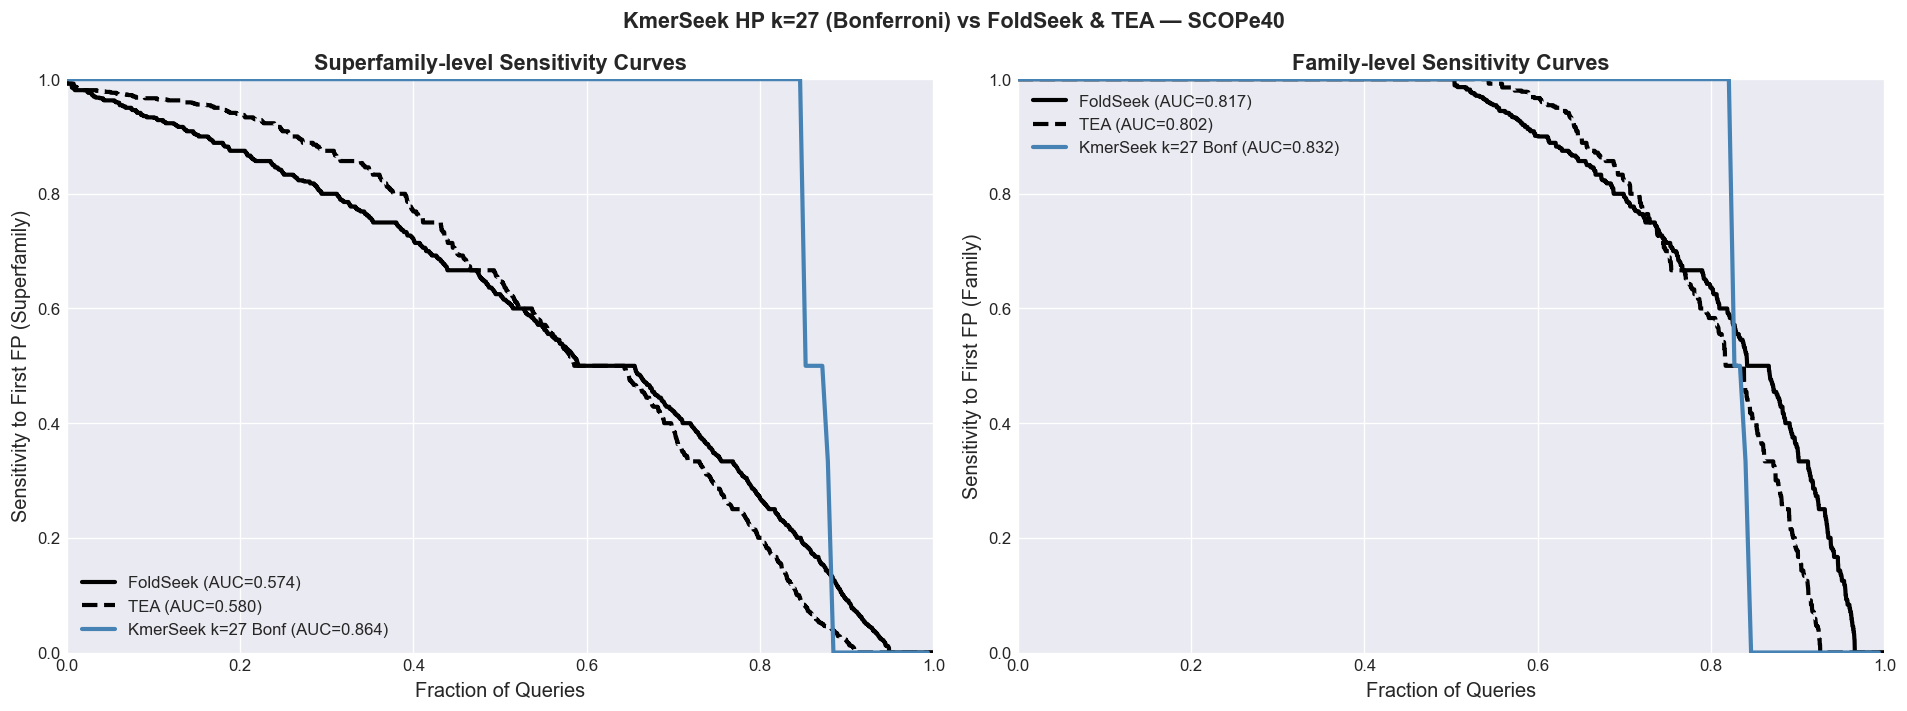

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors_k = {27: 'steelblue'}

for ax, (lc, ll) in zip(axes, [('SFAM', 'Superfamily'), ('FAM', 'Family')]):
    frac, sens, auc = sensitivity_stats(foldseek, lc)
    ax.plot(frac, sens, 'k-', lw=2.5, label=f'FoldSeek (AUC={auc:.3f})')

    frac, sens, auc = sensitivity_stats(tea_all, lc)
    ax.plot(frac, sens, 'k--', lw=2.5, label=f'TEA (AUC={auc:.3f})')

    for k in K_UNIQUE:
        frac, sens, auc = sensitivity_stats(km_rocx_r[k], lc)
        ax.plot(frac, sens, color=colors_k[k], lw=2.5,
                label=f'KmerSeek k={k} Bonf (AUC={auc:.3f})')

    ax.set_xlabel('Fraction of Queries', fontsize=12)
    ax.set_ylabel(f'Sensitivity to First FP ({ll})', fontsize=12)
    ax.set_title(f'{ll}-level Sensitivity Curves', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.suptitle('KmerSeek HP k=27 (Bonferroni) vs FoldSeek & TEA — SCOPe40',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/068_sensitivity_k27.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Unique Hits Analysis

A query is "detected by method X" if its sensitivity at the superfamily level > 0
(i.e., at least one true homolog was found before the first FP).

We identify queries where KmerSeek has sensitivity > 0 but **neither** FoldSeek
nor TEA does.


In [6]:
def detected_queries(rocx_df: pl.DataFrame, level_col: str = 'SFAM') -> set:
    """Return set of query IDs with sensitivity > 0 at the given level."""
    return set(rocx_df.filter(pl.col(level_col) > 0)['NAME'].to_list())


fs_detected   = detected_queries(foldseek)
tea_detected  = detected_queries(tea_all)
base_detected = fs_detected | tea_detected   # union of baselines

print(f'FoldSeek detected:   {len(fs_detected):,} queries')
print(f'TEA detected:        {len(tea_detected):,} queries')
print(f'Either baseline:     {len(base_detected):,} queries')
print()

for k in K_UNIQUE:
    km_det = detected_queries(km_rocx[k])
    unique = km_det - base_detected
    pct_unique = 100 * len(unique) / len(km_det) if km_det else 0
    overlap = km_det & base_detected
    print(f'k={k} (Bonferroni):')
    print(f'  KmerSeek detected:          {len(km_det):,} queries')
    print(f'  Unique to KmerSeek:         {len(unique):,} ({pct_unique:.1f}% of KmerSeek hits)')
    print(f'  Shared with FoldSeek/TEA:   {len(overlap):,}')
    print()


FoldSeek detected:   5,421 queries
TEA detected:        5,214 queries
Either baseline:     5,508 queries

k=27 (Bonferroni):
  KmerSeek detected:          366 queries
  Unique to KmerSeek:         233 (63.7% of KmerSeek hits)
  Shared with FoldSeek/TEA:   133



## 5. SCOPe Class Distribution of Unique vs All Hits

In [7]:
def scop_class_from_rocx(rocx_df: pl.DataFrame) -> list:
    """Extract the first character of the SCOP lineage (the class) for each row."""
    return (
        rocx_df
        .filter(pl.col('SCOP').str.len_chars() > 0)
        ['SCOP']
        .str.slice(0, 1)
        .to_list()
    )


# Collect class distributions for k=27 (representative)
k_plot = 27
km_det_all    = detected_queries(km_rocx[k_plot])
km_det_unique = km_det_all - base_detected

rocx_all    = km_rocx[k_plot]
rocx_unique = rocx_all.filter(pl.col('NAME').is_in(km_det_unique))

classes_km_all    = scop_class_from_rocx(rocx_all.filter(pl.col('NAME').is_in(km_det_all)))
classes_km_unique = scop_class_from_rocx(rocx_unique)
classes_fs        = scop_class_from_rocx(foldseek.filter(pl.col('SFAM') > 0))
classes_tea       = scop_class_from_rocx(tea_all.filter(pl.col('SFAM') > 0))

def class_pct(classes: list) -> dict:
    """Return percentage distribution over SCOPe classes."""
    total = len(classes)
    if total == 0:
        return {}
    c = Counter(classes)
    return {cls: 100 * count / total for cls, count in sorted(c.items())}

pct_km_unique = class_pct(classes_km_unique)
pct_km_all    = class_pct(classes_km_all)
pct_fs        = class_pct(classes_fs)
pct_tea       = class_pct(classes_tea)

all_classes = sorted(set(list(pct_km_unique) + list(pct_km_all) + list(pct_fs) + list(pct_tea)))

print('SCOPe class distribution (% of detected queries):')
print(f'{'Class':<6} {'HP Unique':>10} {'HP All':>10} {'FoldSeek':>10} {'TEA':>10}  Description')
print('-' * 80)
for cls in all_classes:
    desc = SCOPE_CLASS_DESCRIPTIONS.get(cls, '?')[:40]
    print(f'{cls:<6} {pct_km_unique.get(cls, 0):>10.1f} {pct_km_all.get(cls, 0):>10.1f}'
          f' {pct_fs.get(cls, 0):>10.1f} {pct_tea.get(cls, 0):>10.1f}  {desc}')


SCOPe class distribution (% of detected queries):
Class   HP Unique     HP All   FoldSeek        TEA  Description
--------------------------------------------------------------------------------
a            14.2       13.4       17.6       18.1  All alpha proteins
b             9.0       10.9       30.1       29.4  All beta proteins
c            47.2       51.6       29.7       30.0  Alpha and beta proteins (a/b) — alternat
d            21.9       18.3       19.4       19.0  Alpha and beta proteins (a+b) — segregat
e             3.4        2.2        0.0        0.0  Multi-domain proteins (alpha and beta)
f             3.9        3.3        1.1        1.1  Membrane and cell surface proteins
g             0.4        0.3        2.1        2.4  Small proteins


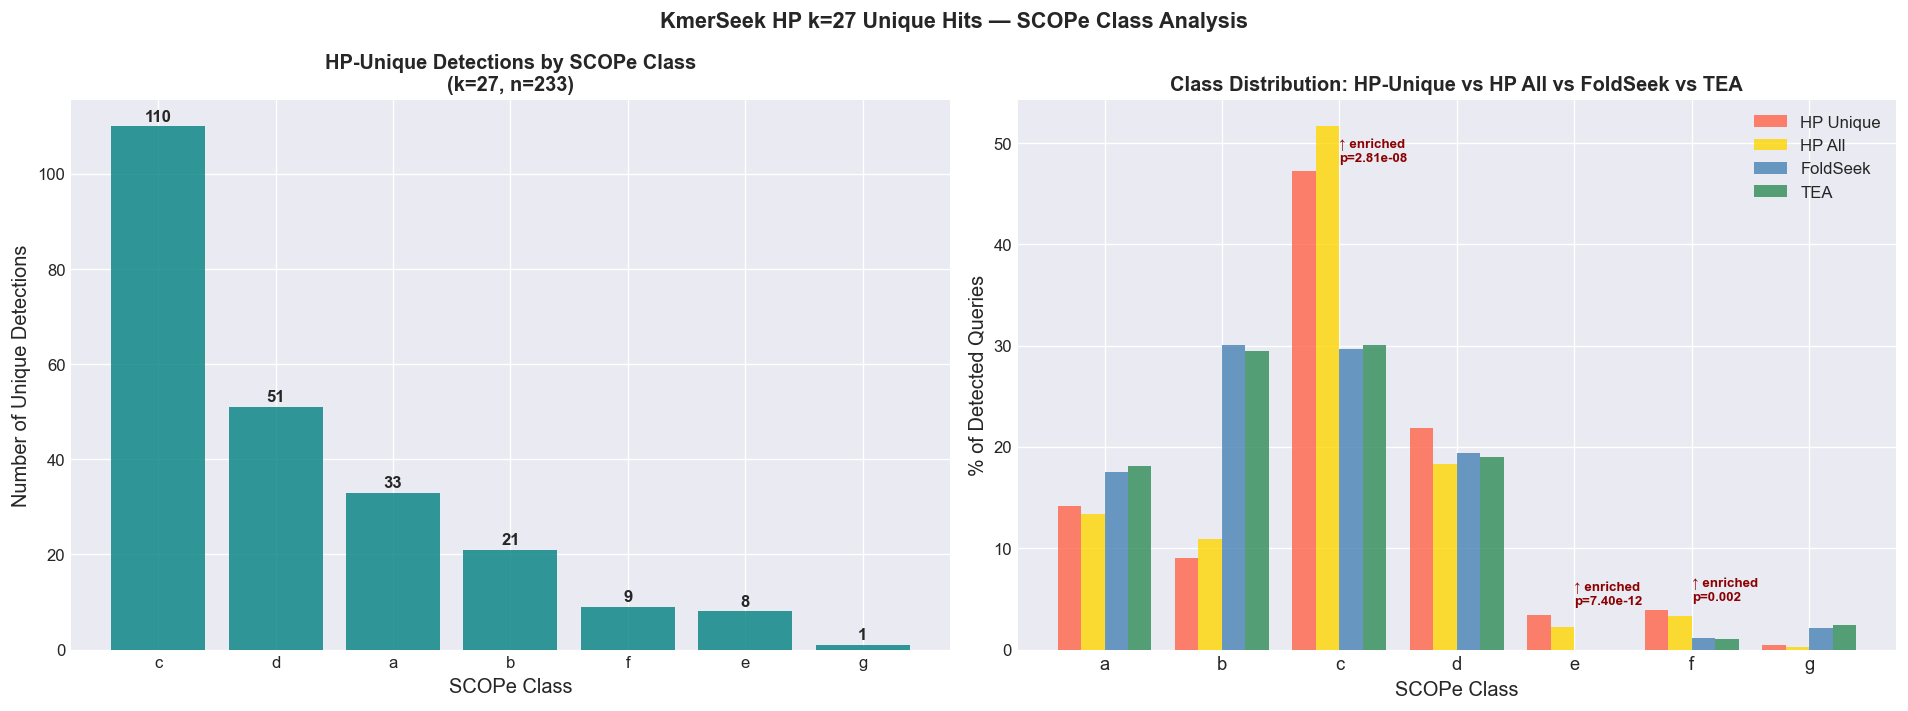

In [8]:
from scipy.stats import fisher_exact

# Bar chart: count of unique detections per class
count_unique = Counter(classes_km_unique)

# Fisher exact: HP-unique vs FoldSeek class distribution (one-sided, enrichment)
n_hp = len(classes_km_unique)
n_fs = len(classes_fs)

def enrichment_pval(cls):
    n_hp_cls   = sum(1 for c in classes_km_unique if c == cls)
    n_fs_cls   = sum(1 for c in classes_fs        if c == cls)
    _, pval = fisher_exact(
        [[n_hp_cls, n_hp - n_hp_cls],
         [n_fs_cls, n_fs - n_fs_cls]],
        alternative='greater')
    return pval

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: raw counts of HP-unique detections
ax = axes[0]
classes_sorted = sorted(count_unique, key=lambda c: -count_unique[c])
counts_sorted  = [count_unique[c] for c in classes_sorted]
bars = ax.bar(classes_sorted, counts_sorted, color='teal', alpha=0.8)
for bar, val in zip(bars, counts_sorted):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xlabel('SCOPe Class', fontsize=12)
ax.set_ylabel('Number of Unique Detections', fontsize=12)
ax.set_title(f'HP-Unique Detections by SCOPe Class\n(k={k_plot}, n={len(classes_km_unique)})',
             fontsize=12, fontweight='bold')

# Right: class distribution comparison (%)
ax = axes[1]
x  = np.arange(len(all_classes))
w  = 0.2
datasets = [
    ('HP Unique', pct_km_unique, 'tomato'),
    ('HP All',    pct_km_all,    'gold'),
    ('FoldSeek',  pct_fs,        'steelblue'),
    ('TEA',       pct_tea,       'seagreen'),
]
for i, (name, pcts, color) in enumerate(datasets):
    vals = [pcts.get(c, 0) for c in all_classes]
    ax.bar(x + i * w, vals, width=w, label=name, color=color, alpha=0.8)

ax.set_xticks(x + 1.5 * w)
ax.set_xticklabels(all_classes, fontsize=11)
ax.set_xlabel('SCOPe Class', fontsize=12)
ax.set_ylabel('% of Detected Queries', fontsize=12)
ax.set_title('Class Distribution: HP-Unique vs HP All vs FoldSeek vs TEA',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)

# Annotate enriched classes with p-value
for cls in ['c', 'e', 'f']:
    if cls in all_classes:
        xi = all_classes.index(cls)
        hp_pct = pct_km_unique.get(cls, 0)
        fs_pct = pct_fs.get(cls, 0)
        if hp_pct > fs_pct * 1.2:
            pval = enrichment_pval(cls)
            pval_str = f'p={pval:.2e}' if pval < 0.001 else f'p={pval:.3f}'
            ax.annotate(f'↑ enriched\n{pval_str}',
                        xy=(xi + 0.3, hp_pct + 1),
                        fontsize=8, color='darkred', fontweight='bold')

plt.suptitle(f'KmerSeek HP k={k_plot} Unique Hits — SCOPe Class Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/068_hp_unique_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Class Enrichment: Why Does KmerSeek Enrich for c, e, f?

| Class | Description | Why KmerSeek finds them |
|---|---|---|
| **c** α/β | TIM barrel, Rossmann fold | HP pattern alternates H and P in regular α-β-α motifs; highly conserved hydrophobic core is captured even at large k |
| **e** Multi-domain | Two or more distinct structural domains fused | HP encoding captures domain-level patterns; FoldSeek needs full 3D structure of each domain |
| **f** Membrane | Transmembrane helices | Transmembrane helices are nearly pure H runs; very distinctive HP signature, missed by structure tools lacking membrane context |

### Sphingolipid Pathway Connection

Most enzymes in the ceramide/sphingolipid de novo synthesis pathway fall into
class c or f:


In [9]:
# Sphingolipid pathway enzymes and their SCOPe classes
sphingolipid_enzymes = [
    ('SPT (SPTLC1-3)',   'Class c (c.67)', 'PLP-dependent transferase',      'Serine + Palmitoyl-CoA → 3-KDS'),
    ('KDSR',             'Class c (c.2)',  'Rossmann NADP(H)',               '3-KDS → Dihydrosphingosine'),
    ('CERS1-6',          'Class f',        'TLC transmembrane domain',        'Sphingoid base + Acyl-CoA → Ceramide'),
    ('DEGS1/DEGS2',      'Class a/f',      'Membrane fatty acid desaturase',  'Dihydroceramide → Ceramide'),
    ('SPHK1/2',          'Class c (c.56)', 'DAGK-like kinase',               'Sphingosine → S1P'),
    ('SGPL1',            'Class c (c.67)', 'PLP-dependent lyase',            'S1P → Phosphoethanolamine + Hexadecenal'),
    ('CERK',             'Class c (c.56)', 'DAGK-like kinase',               'Ceramide → Ceramide-1-Phosphate'),
    ('CYP4F2',           'Class a (a.7)',  'Cytochrome P450 (all-alpha)',     'ω-hydroxylation of sphingosine/LTB4'),
    ('CYP4F8/CYP4F12',   'Class a (a.7)',  'Cytochrome P450 (all-alpha)',     'Fatty acid/sphingolipid ω-oxidation'),
]

print(f'{"Enzyme":<22} {"SCOPe Class":<18} {"Fold/SF":<30} {"Pathway Step":<50}')
print('-' * 124)
for enzyme, cls, fold, step in sphingolipid_enzymes:
    print(f'{enzyme:<22} {cls:<18} {fold:<30} {step:<50}')

print()
print('Class a (CYP4F2 / CYP4F family):')
print('  - Cytochrome P450s are all-alpha (class a, a.7 family)')
print('  - CYP4F2 performs ω-hydroxylation of sphingosine and leukotriene B4')
print('  - HP encoding captures hydrophobic transmembrane helix + long polyPro-like runs')
print('  - KmerSeek HP may uniquely detect CYP4F2 because FoldSeek misses')
print('    the hydrophobic surface patches shared with other membrane P450s')
print()
print('Class c dominates because:')
print('  - Rossmann folds (c.2) bind NADP(H) for reduction steps')
print('  - PLP-dependent folds (c.67) for carbon-carbon bond chemistry')
print('  - DAGK-like folds (c.56) for lipid kinases')
print()
print('Class f appears for membrane-embedded enzymes (CERS, DEGS) whose active sites')
print('require transmembrane helix scaffolding — these have pure-H HP runs.')


Enzyme                 SCOPe Class        Fold/SF                        Pathway Step                                      
----------------------------------------------------------------------------------------------------------------------------
SPT (SPTLC1-3)         Class c (c.67)     PLP-dependent transferase      Serine + Palmitoyl-CoA → 3-KDS                    
KDSR                   Class c (c.2)      Rossmann NADP(H)               3-KDS → Dihydrosphingosine                        
CERS1-6                Class f            TLC transmembrane domain       Sphingoid base + Acyl-CoA → Ceramide              
DEGS1/DEGS2            Class a/f          Membrane fatty acid desaturase Dihydroceramide → Ceramide                        
SPHK1/2                Class c (c.56)     DAGK-like kinase               Sphingosine → S1P                                 
SGPL1                  Class c (c.67)     PLP-dependent lyase            S1P → Phosphoethanolamine + Hexadecenal           
CERK   

In [10]:
# ── Fisher's exact test: enrichment of KmerSeek-unique hits by SCOPe class ───
from scipy.stats import fisher_exact

# Use k_plot; km_det_all and base_detected defined in cell 9
km_unique_ids = km_det_all - base_detected
km_shared_ids = km_det_all & base_detected

def cls_from_rocx(rocx_df, query_set):
    """Map query -> SCOPe class (first char of SCOP lineage)."""
    sub = (rocx_df
           .filter(pl.col('NAME').is_in(query_set))
           .select(['NAME', 'SCOP'])
           .unique()
           .with_columns(pl.col('SCOP').str.slice(0, 1).alias('cls')))
    return dict(zip(sub['NAME'].to_list(), sub['cls'].to_list()))

cls_unique = cls_from_rocx(km_rocx[k_plot], km_unique_ids)
cls_shared = cls_from_rocx(km_rocx[k_plot], km_shared_ids)
all_cls    = sorted(set(cls_unique.values()) | set(cls_shared.values()))

print(f'KmerSeek-unique: {len(km_unique_ids)} queries')
print(f'KmerSeek-shared: {len(km_shared_ids)} queries')
print()
print(f'{"Class":<6} {"Description":<35} {"Unique":>7} {"Shared":>7} {"OR":>7} {"p-value":>10}  {"FDR (BH)":>10}')
print('-' * 90)

fisher_rows = []
for cls in all_cls:
    n_unique_cls  = sum(1 for c in cls_unique.values() if c == cls)
    n_unique_rest = len(km_unique_ids) - n_unique_cls
    n_shared_cls  = sum(1 for c in cls_shared.values() if c == cls)
    n_shared_rest = len(km_shared_ids) - n_shared_cls
    table = [[n_unique_cls, n_unique_rest],
             [n_shared_cls, n_shared_rest]]
    OR, pval = fisher_exact(table, alternative='greater')
    fisher_rows.append((cls, n_unique_cls, n_shared_cls, OR, pval))

# BH FDR correction
pvals = [r[4] for r in fisher_rows]
n = len(pvals)
ranked = sorted(range(n), key=lambda i: pvals[i])
fisher_fdr = [0.0] * n
for rank, i in enumerate(ranked):
    fisher_fdr[i] = min(1.0, pvals[i] * n / (rank + 1))
# make monotone
for i in range(n - 2, -1, -1):
    fisher_fdr[ranked[i]] = min(fisher_fdr[ranked[i]], fisher_fdr[ranked[i + 1]])

for idx, (cls, n_u, n_s, OR, pval) in enumerate(fisher_rows):
    desc = SCOPE_CLASS_DESCRIPTIONS.get(cls, '?')[:34]
    sig  = '***' if fisher_fdr[idx] < 0.001 else ('**' if fisher_fdr[idx] < 0.01 else ('*' if fisher_fdr[idx] < 0.05 else ''))
    print(f'{cls:<6} {desc:<35} {n_u:>7} {n_s:>7} {OR:>7.2f} {pval:>10.4f}  {fisher_fdr[idx]:>10.4f}  {sig}')

print()
print('OR = odds ratio (>1 = enriched in KmerSeek-unique vs shared)')
print('p-value: one-sided Fisher exact (enrichment direction)')
print('FDR: Benjamini-Hochberg correction across SCOPe classes')


KmerSeek-unique: 233 queries
KmerSeek-shared: 133 queries

Class  Description                          Unique  Shared      OR    p-value    FDR (BH)
------------------------------------------------------------------------------------------
a      All alpha proteins                       33      16    1.21     0.3419      0.5983  
b      All beta proteins                        21      19    0.59     0.9565      0.9908  
c      Alpha and beta proteins (a/b) — al      110      79    0.61     0.9908      0.9908  
d      Alpha and beta proteins (a+b) — se       51      16    2.05     0.0123      0.0861  
e      Multi-domain proteins (alpha and b        8       0     inf     0.0258      0.0903  
f      Membrane and cell surface proteins        9       3    1.74     0.3078      0.5983  
g      Small proteins                            1       0     inf     0.6366      0.8913  

OR = odds ratio (>1 = enriched in KmerSeek-unique vs shared)
p-value: one-sided Fisher exact (enrichment direction)

In [11]:
# ── Overlapping kmer regions for KmerSeek-unique hits — organised by SCOPe class
import textwrap

results_path = BENCH_DIR / f'scope40.hp.k{k_plot}.results.csv.gz'
print(f'Loading {results_path.name} ...')
res = pl.read_csv(results_path)
print(f'  {len(res):,} total hits')

res = res.with_columns([
    pl.col('query_name').str.split(' ').list.get(0).alias('query_domain'),
    pl.col('target_name').str.split(' ').list.get(0).alias('target_domain'),
])

unique_hits = (res
    .filter(pl.col('query_domain').is_in(km_unique_ids))
    .filter(pl.col('poisson_pvalue') < ALPHA)
    .filter(pl.col('query_subseq').is_not_null())
    .sort(['query_domain', 'poisson_pvalue'])
)
print(f'  {len(unique_hits):,} hits from {unique_hits["query_domain"].n_unique()} '
      f'unique-KmerSeek queries after pval<{ALPHA} filter')

# Domain metadata
domains  = pl.read_csv(BENCH_DIR / 'scope_domains.tsv', separator='\t')
dom_map  = dict(zip(domains['domain_id'], domains['protein_name']))
scop_map = dict(zip(domains['domain_id'], domains['scop_id']))

# Best hit per query (lowest p-value)
best_per_query = (unique_hits
    .sort('poisson_pvalue')
    .group_by('query_domain')
    .agg([pl.first(c) for c in unique_hits.columns if c != 'query_domain'])
)

# Attach SCOPe class from rocx (first char of SCOP lineage)
scop_from_rocx = dict(zip(km_rocx[k_plot]['NAME'], km_rocx[k_plot]['SCOP']))

rows = best_per_query.with_columns(
    pl.col('query_domain')
      .map_elements(lambda d: scop_from_rocx.get(d, scop_map.get(d, '?')), return_dtype=pl.Utf8)
      .alias('query_scop'),
).with_columns(
    pl.col('query_scop').str.slice(0, 1).alias('scop_class')
).sort(['scop_class', 'query_domain'])

# BLOSUM62 positive-score pairs = "similar" (conservative substitutions)
_BLOSUM62_POS = {
    frozenset(p) for p in [
        ('A','S'),('A','T'),('A','G'),('D','E'),('D','N'),('E','Q'),('E','K'),
        ('N','S'),('N','T'),('Q','K'),('R','K'),('I','L'),('I','V'),('I','M'),
        ('L','V'),('L','M'),('F','Y'),('F','W'),('Y','W'),('H','N'),('H','Q'),
        ('S','T'),('V','M'),
    ]
}
_BLOSUM62_POS |= {frozenset((aa, aa)) for aa in 'ACDEFGHIKLMNPQRSTVWY'}  # identity always positive

def pct_id_sim(q_seq, t_seq):
    """Return (% identity, % similarity) over aligned overlapping region."""
    n = min(len(q_seq), len(t_seq))
    if n == 0:
        return 0.0, 0.0
    n_id  = sum(q == t for q, t in zip(q_seq, t_seq))
    n_sim = sum(frozenset((q.upper(), t.upper())) in _BLOSUM62_POS
                for q, t in zip(q_seq, t_seq))
    return 100 * n_id / n, 100 * n_sim / n

# Load overlap disorder cache if available (written by the disorder cell)
_overlap_disorder = {}
for grp_name in ['KmerSeek-unique', 'KmerSeek+baseline']:
    _cache = BENCH_DIR / f'disorder_overlap_{grp_name.replace("+","_").replace("-","_")}_k{k_plot}.parquet'
    if _cache.exists():
        import numpy as np
        for row in pl.read_parquet(_cache).iter_rows(named=True):
            scores = np.array(row['scores'].split(','), dtype=float)
            _overlap_disorder[row['domain']] = scores

# Print grouped by class

for cls in sorted(rows['scop_class'].unique().to_list()):
    cls_desc = SCOPE_CLASS_DESCRIPTIONS.get(cls, cls)
    cls_rows = rows.filter(pl.col('scop_class') == cls)
    print()
    print('=' * 100)
    print(f'  SCOPe CLASS {cls.upper()} — {cls_desc}  ({cls_rows.height} unique queries)')
    print('=' * 100)

    for row in cls_rows.iter_rows(named=True):
        qid  = row['query_domain']
        tid  = row['target_domain']
        q_scop = row['query_scop']
        t_scop = scop_map.get(tid, '?')
        q_prot = dom_map.get(qid, '?')
        t_prot = dom_map.get(tid, '?')

        print(f'  QUERY:  {qid}  SCOP={q_scop}  {q_prot}')
        print(f'  TARGET: {tid}  SCOP={t_scop}  {t_prot}')
        q_seq = row['query_subseq']  or ''
        t_seq = row['target_subseq'] or ''
        hp    = row['moltype_seq']   or ''
        pct_id, pct_sim = pct_id_sim(q_seq, t_seq)
        ov_scores = _overlap_disorder.get(qid)
        ov_str = f'  disorder={ov_scores.mean():.2f} (max={ov_scores.max():.2f})' if ov_scores is not None else ''
        print(f'  pval={row["poisson_pvalue"]:.2e}  jaccard={row["jaccard"]:.4f}'
              f'  containment={row["containment"]:.4f}  region_len={row["region_length"]}'
              f'  %id={pct_id:.1f}%  %sim={pct_sim:.1f}%{ov_str}')
        print()

        width = 80
        for start in range(0, max(len(q_seq), len(t_seq), len(hp)), width):
            q_pos = row['query_start']  + start
            t_pos = row['target_start'] + start
            chunk_q = q_seq[start:start+width]
            chunk_t = t_seq[start:start+width]
            match   = ''.join('|' if a == b else ':' if frozenset((a.upper(),b.upper())) in _BLOSUM62_POS else '.' for a,b in zip(chunk_q, chunk_t))
            prefix_q  = f'    Q[{q_pos:>4}] '
            prefix_t  = f'    T[{t_pos:>4}] '
            prefix_hp = f'    HP      '
            spacer    = ' ' * len(prefix_q)
            print(prefix_q  + chunk_q)
            print(spacer    + match)
            print(prefix_t  + chunk_t)
            print(prefix_hp + hp[start:start+width])
            print()

        print('  ' + '-' * 98)


Loading scope40.hp.k27.results.csv.gz ...
  11,519 total hits
  603 hits from 233 unique-KmerSeek queries after pval<0.001 filter

  SCOPe CLASS A — All alpha proteins  (33 unique queries)
  QUERY:  d1sj8a2  SCOP=a.216.1.1  Talin 1
  TARGET: d1f0xa2  SCOP=d.145.1.1  D-lactate dehydrogenase
  pval=5.52e-08  jaccard=0.0090  containment=0.0303  region_len=29  %id=6.9%  %sim=10.3%  disorder=0.91 (max=1.00)

    Q[  87] KAVEGCVSASQAATEDGQLLRGVGAAATA
            ................|...:....|...
    T[ 230] TPARYNADPDRLFESSGCAGKLAVFAVRL
    HP      phhphphphpphhppphphhphhhhhhph

  --------------------------------------------------------------------------------------------------
  QUERY:  d1tbfa_  SCOP=a.211.1.2  cGMP-specific 3',5'-cyclic phosphodiesterase pde5a1-Ibmx
  TARGET: d1y2ka_  SCOP=a.211.1.2  Catalytic domain of cyclic nucleotide phosphodiesterase pde4d
  pval=0.00e+00  jaccard=0.0152  containment=0.0300  region_len=35  %id=88.6%  %sim=94.3%  disorder=0.83 (max=0.95)

    Q[ 119] HDLDH

Pairplot: 603 unique-KmerSeek hits
same FAM      442
same SFAM     474
same FOLD     474
same CLASS    521
dtype: int64



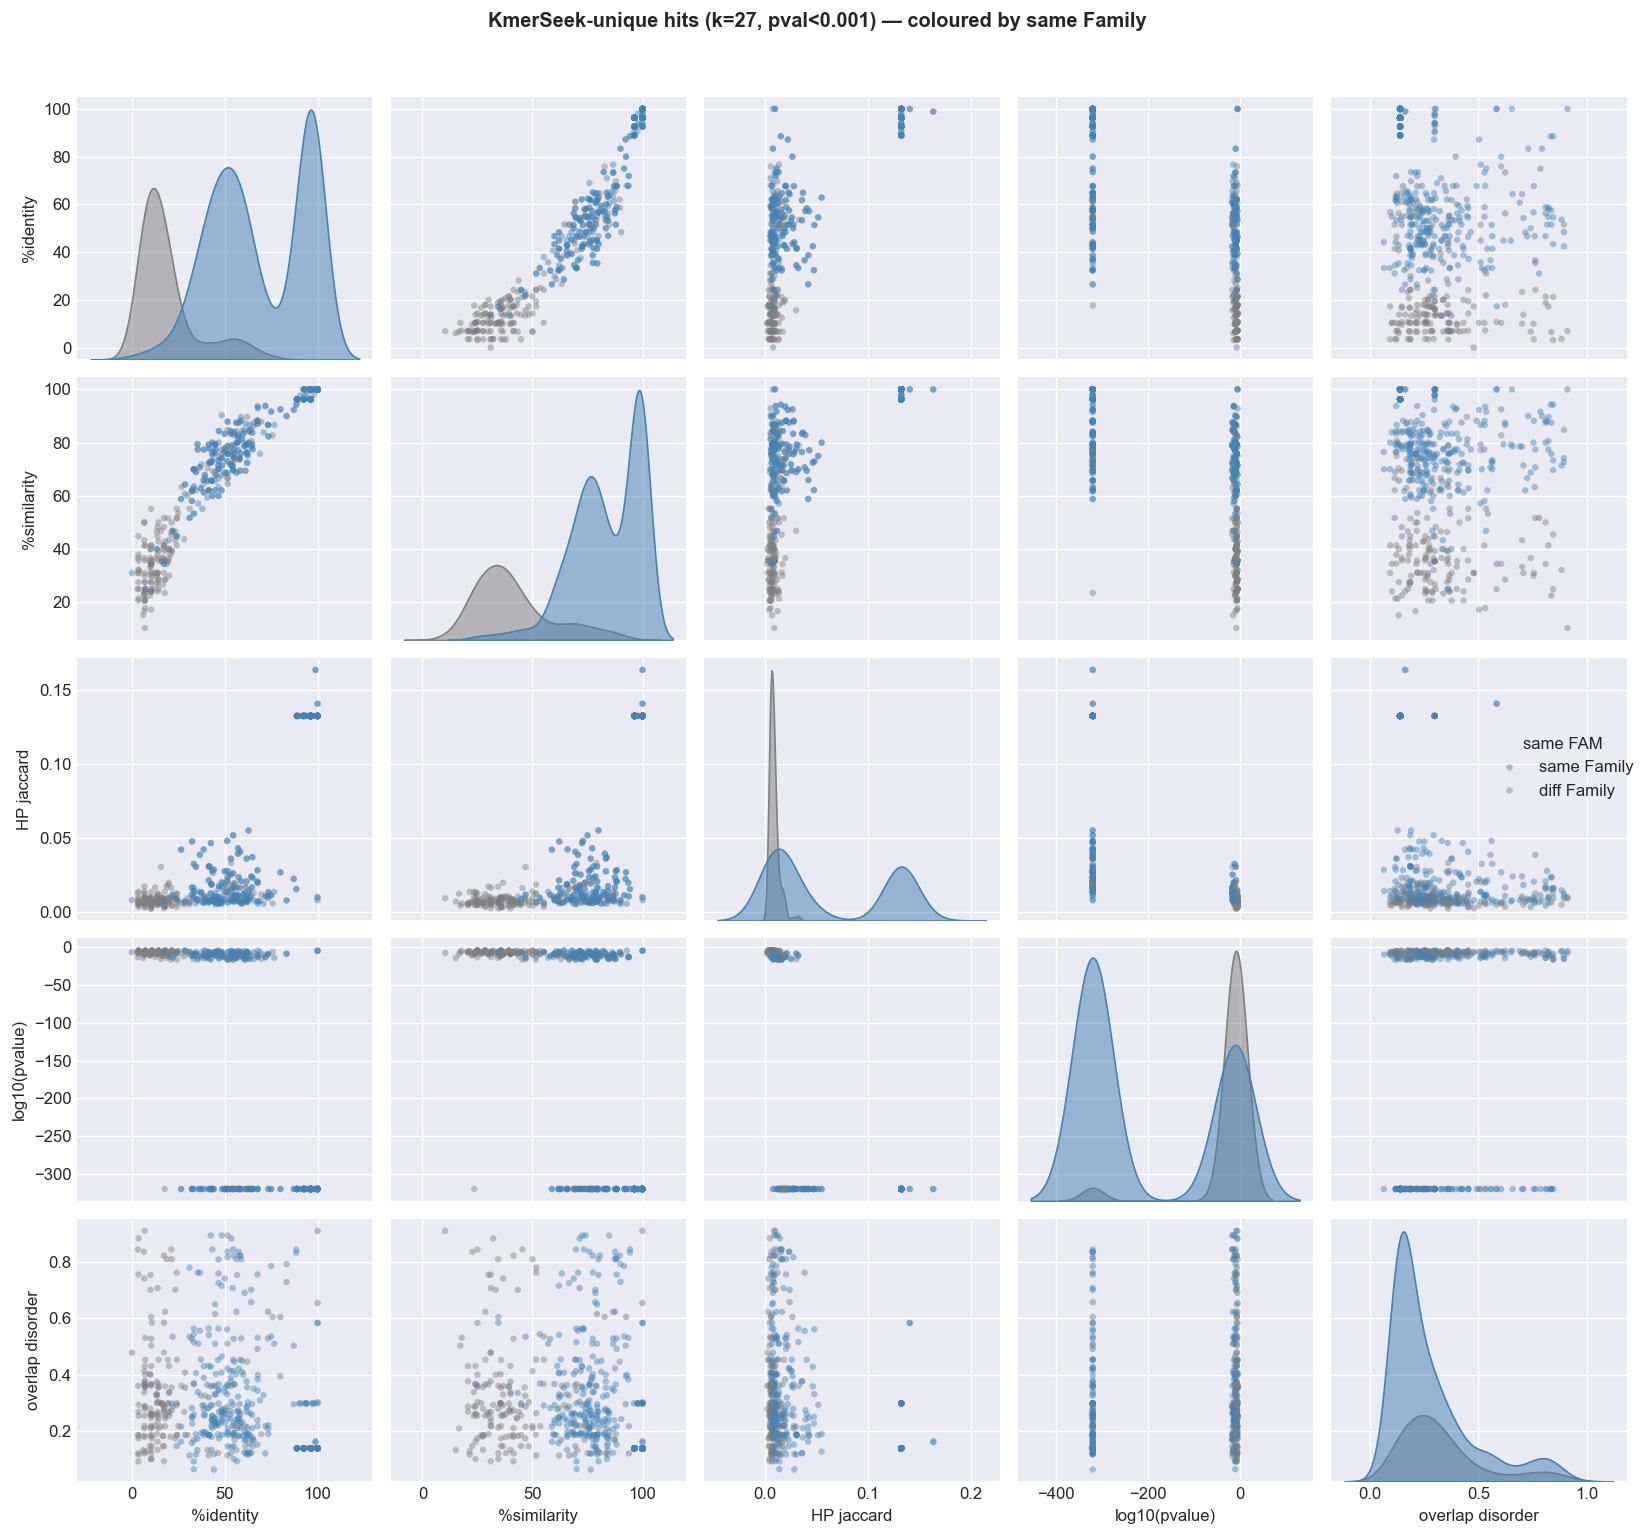

Saved pairplot_family.png


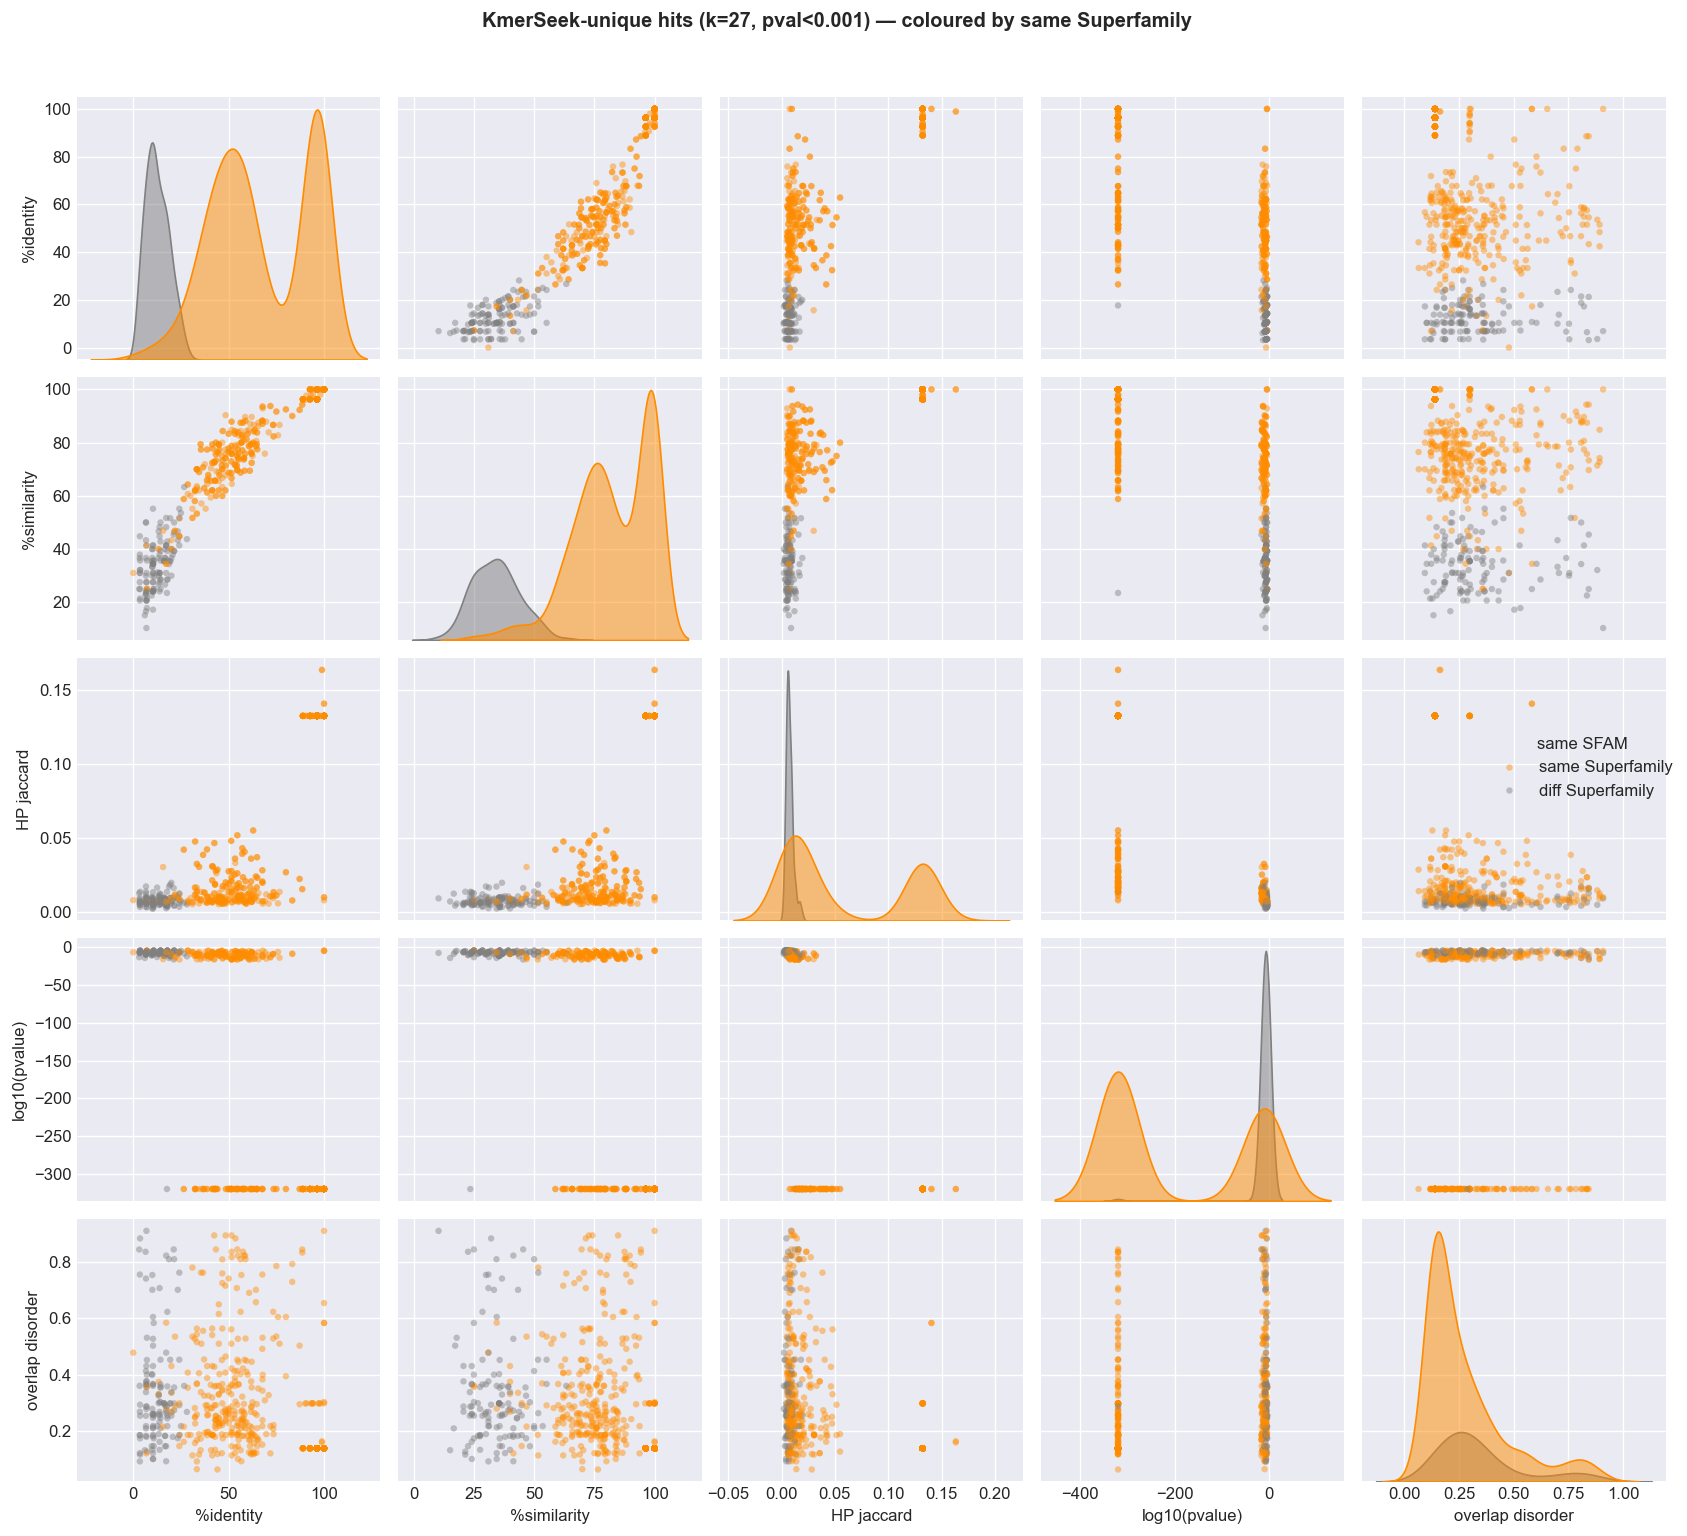

Saved pairplot_superfamily.png


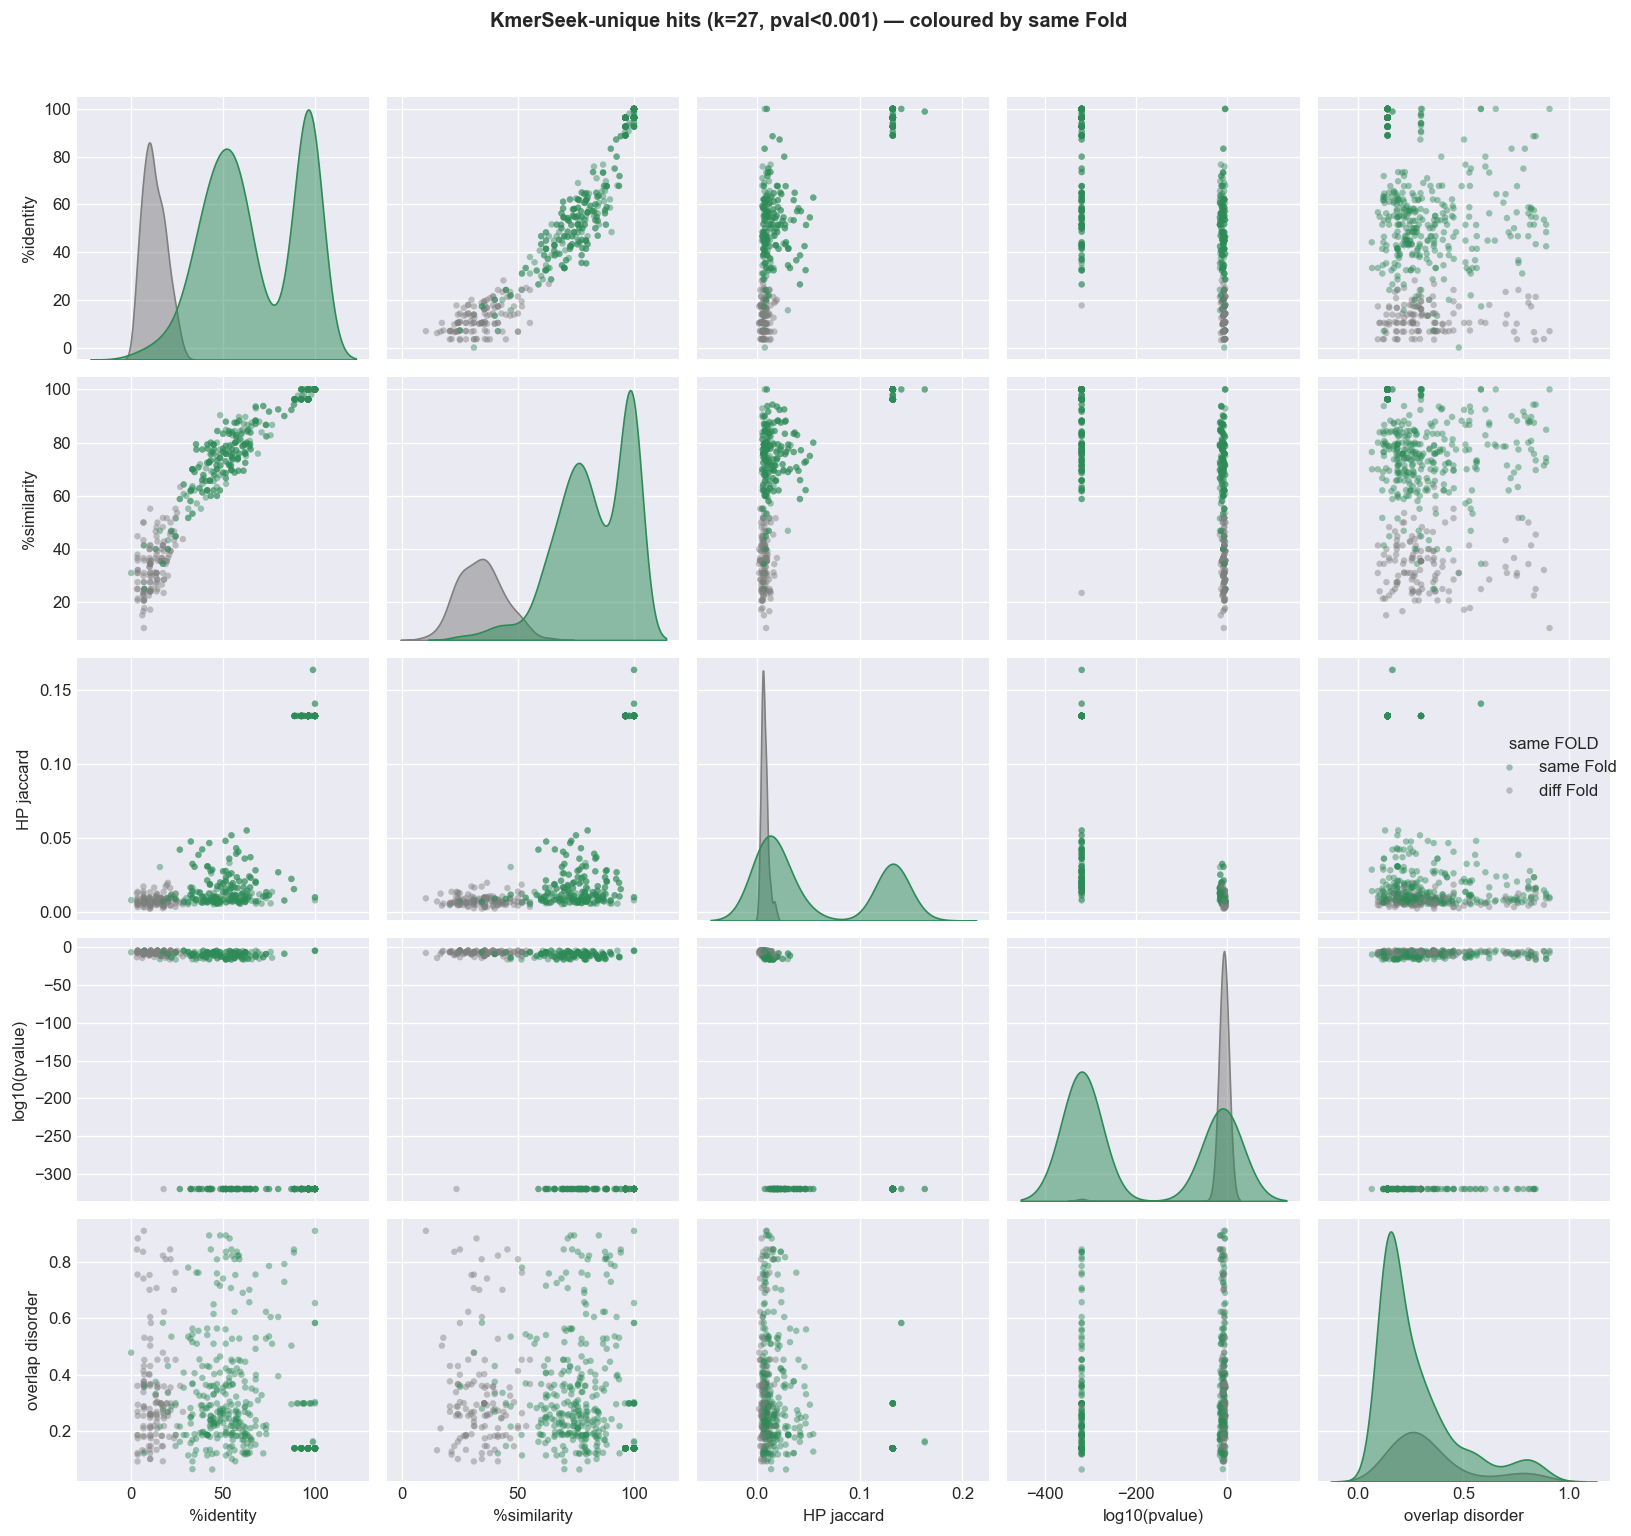

Saved pairplot_fold.png


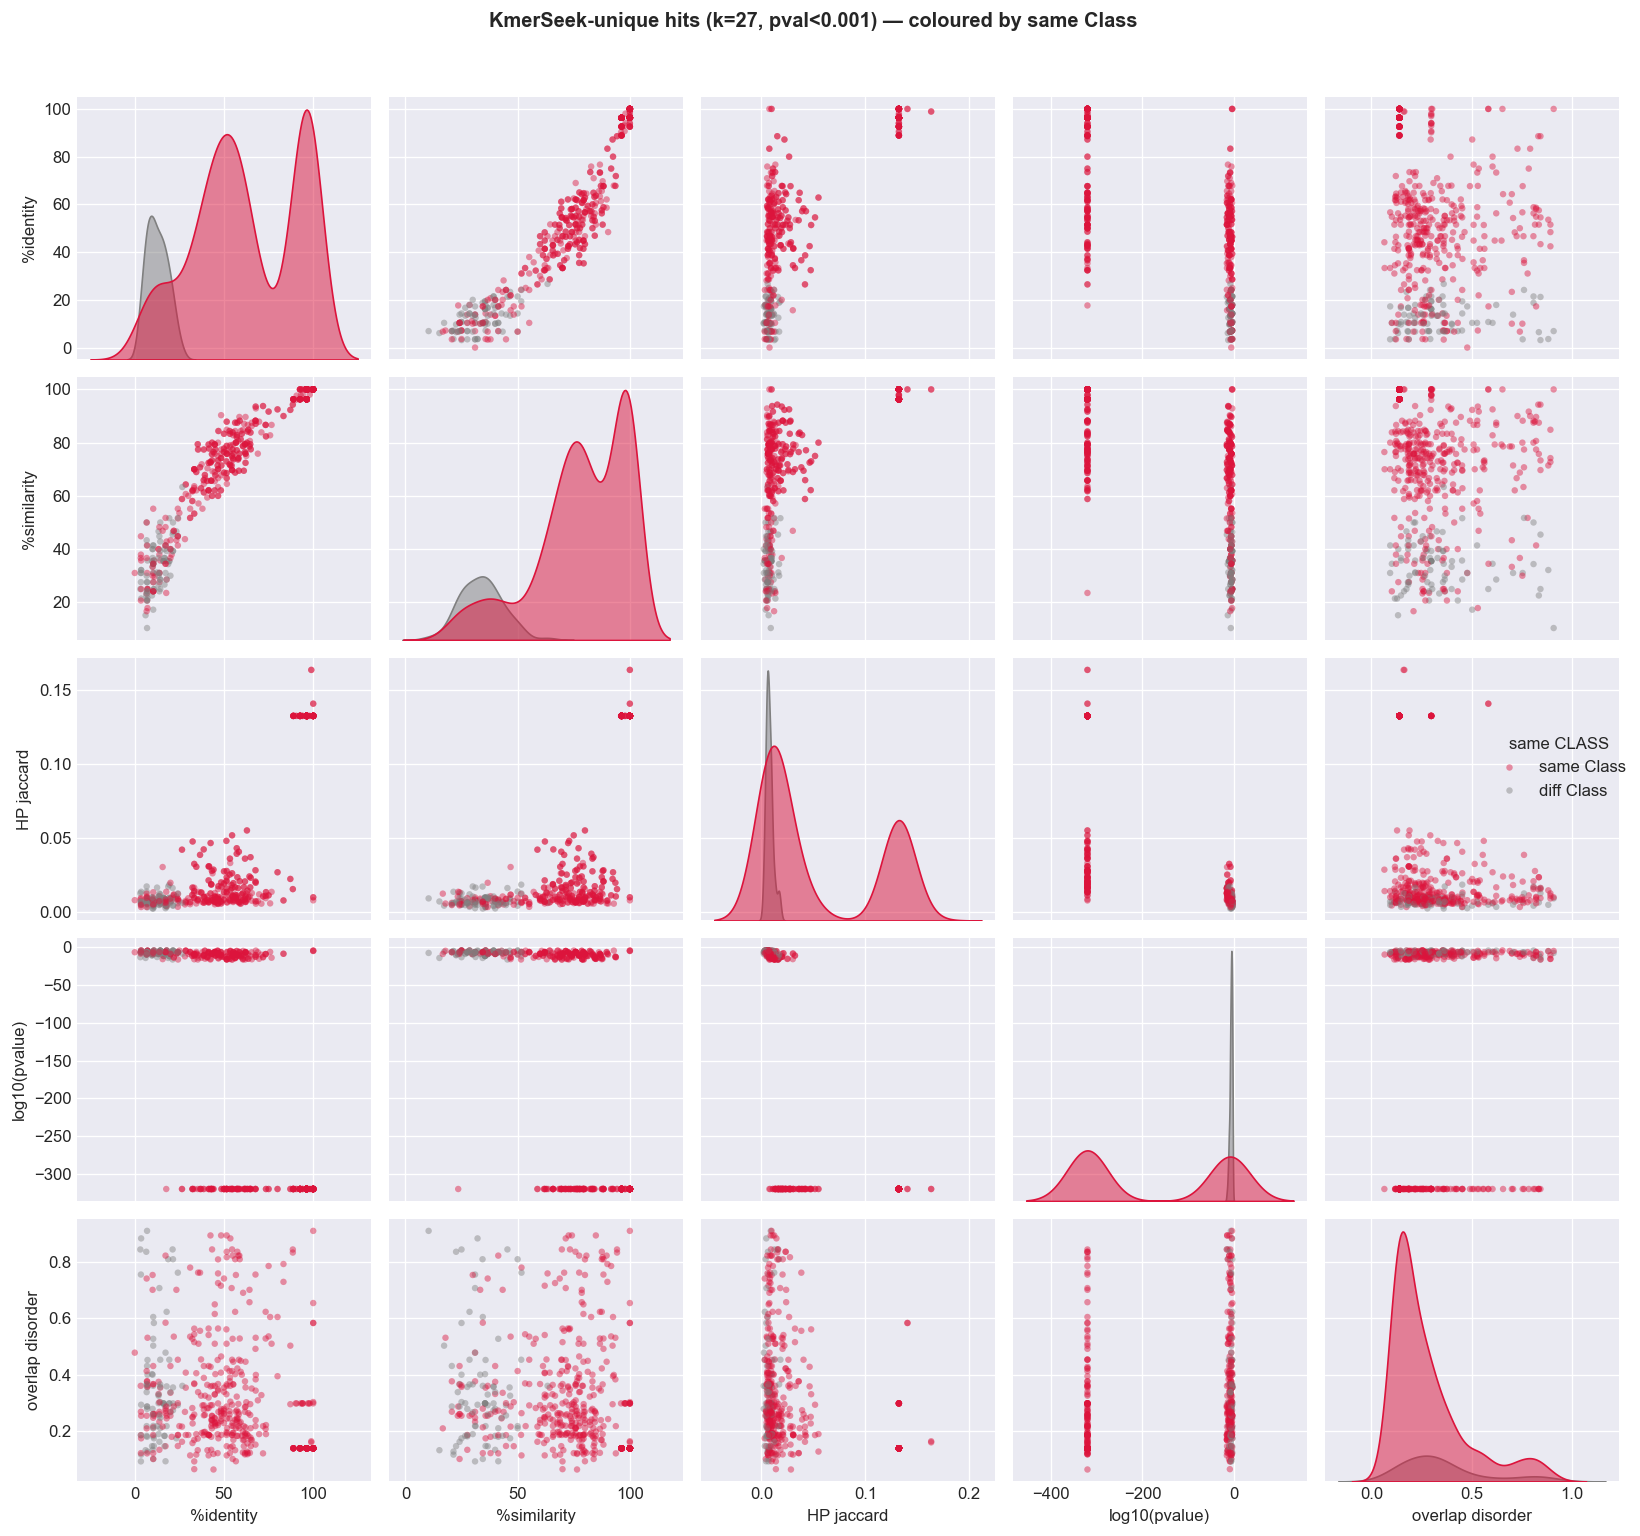

Saved pairplot_class.png


In [12]:
# ── Pairplot: %id, %sim, HP jaccard, log10(pvalue), overlap disorder ──────────
# Four pairplots: coloured by same FAM / SFAM / FOLD / CLASS
import seaborn as sns
import numpy as np

# Re-use unique_hits, pct_id_sim, scop_map from cell 17
# Load overlap disorder cache
_overlap_disorder = {}
_cache = BENCH_DIR / f'disorder_overlap_KmerSeek_unique_k{k_plot}.parquet'
if _cache.exists():
    for row in pl.read_parquet(_cache).iter_rows(named=True):
        _overlap_disorder[row['domain']] = np.array(row['scores'].split(','), dtype=float)

def scop_level(scop_id: str, n_parts: int) -> str:
    """Return the first n_parts of a dotted SCOP lineage, e.g. 'a.1.1'."""
    return '.'.join(scop_id.split('.')[:n_parts]) if scop_id else ''

# Build per-hit dataframe (all unique-query hits, best per target)
pair_rows = []
for row in (unique_hits
            .filter(pl.col('query_domain').is_in(km_unique_ids))
            .iter_rows(named=True)):
    qid = row['query_domain']
    tid = row['target_domain']
    q_seq = row['query_subseq'] or ''
    t_seq = row['target_subseq'] or ''
    if not q_seq or not t_seq:
        continue
    pct_id, pct_sim = pct_id_sim(q_seq, t_seq)
    ov_scores = _overlap_disorder.get(qid)

    q_scop = scop_map.get(qid, '')
    t_scop = scop_map.get(tid, '')

    pair_rows.append({
        '%identity':        pct_id,
        '%similarity':      pct_sim,
        'HP jaccard':       row['jaccard'],
        'log10(pvalue)':    np.log10(max(row['poisson_pvalue'], 1e-320)),
        'overlap disorder': float(ov_scores.mean()) if ov_scores is not None else np.nan,
        'same FAM':   scop_level(q_scop, 4) == scop_level(t_scop, 4) and bool(scop_level(q_scop, 4)),
        'same SFAM':  scop_level(q_scop, 3) == scop_level(t_scop, 3) and bool(scop_level(q_scop, 3)),
        'same FOLD':  scop_level(q_scop, 2) == scop_level(t_scop, 2) and bool(scop_level(q_scop, 2)),
        'same CLASS': scop_level(q_scop, 1) == scop_level(t_scop, 1) and bool(scop_level(q_scop, 1)),
    })

pair_df = pl.DataFrame(pair_rows).to_pandas().dropna(subset=['%identity','%similarity','HP jaccard','log10(pvalue)','overlap disorder'])
print(f'Pairplot: {len(pair_df)} unique-KmerSeek hits')
print(pair_df[['same FAM','same SFAM','same FOLD','same CLASS']].sum())
print()

FEAT_COLS = ['%identity','%similarity','HP jaccard','log10(pvalue)','overlap disorder']
LEVELS    = [('same FAM',   'Family',       {True: 'steelblue',  False: 'grey'}),
             ('same SFAM',  'Superfamily',  {True: 'darkorange', False: 'grey'}),
             ('same FOLD',  'Fold',         {True: 'seagreen',   False: 'grey'}),
             ('same CLASS', 'Class',        {True: 'crimson',    False: 'grey'})]

for hue_col, level_name, pal in LEVELS:
    sub = pair_df[FEAT_COLS + [hue_col]].copy()
    sub[hue_col] = sub[hue_col].map({True: f'same {level_name}', False: f'diff {level_name}'})
    hue_order = [f'same {level_name}', f'diff {level_name}']
    palette   = {f'same {level_name}': list(pal.values())[0],
                 f'diff {level_name}': list(pal.values())[1]}

    g = sns.pairplot(sub, hue=hue_col, hue_order=hue_order,
                     palette=palette, diag_kind='kde',
                     plot_kws=dict(alpha=0.45, s=15, linewidth=0),
                     diag_kws=dict(fill=True, alpha=0.5))
    g.figure.suptitle(
        f'KmerSeek-unique hits (k={k_plot}, pval<{ALPHA}) — coloured by same {level_name}',
        y=1.02, fontsize=12, fontweight='bold')
    plt.tight_layout()
    safe = level_name.lower()
    plt.savefig(f'../figures/068_pairplot_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved pairplot_{safe}.png')


Parsing /Users/olga/data/scope/astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa ...
  Parsed 15,177 sequences
  Loading cached full-protein disorder — KmerSeek-unique
    mean disorder = 0.0912    has_any_IDR = 17.6%
  Loading cached full-protein disorder — KmerSeek+baseline
    mean disorder = 0.1026    has_any_IDR = 17.3%
  Loading cached full-protein disorder — FoldSeek/TEA-only
    mean disorder = 0.1265    has_any_IDR = 22.4%
  Loading cached overlap disorder — KmerSeek-unique
    overlap mean disorder = 0.3515
  Loading cached overlap disorder — KmerSeek+baseline
    overlap mean disorder = 0.3700

Group                      n   mean disorder   has ANY IDR   mean frac IDR
--------------------------------------------------------------------------
KmerSeek-unique          233          0.0912         17.6%            1.9%
KmerSeek+baseline        133          0.1026         17.3%            1.4%
FoldSeek/TEA-only       5375          0.1265         22.4%            3.1%

Group        

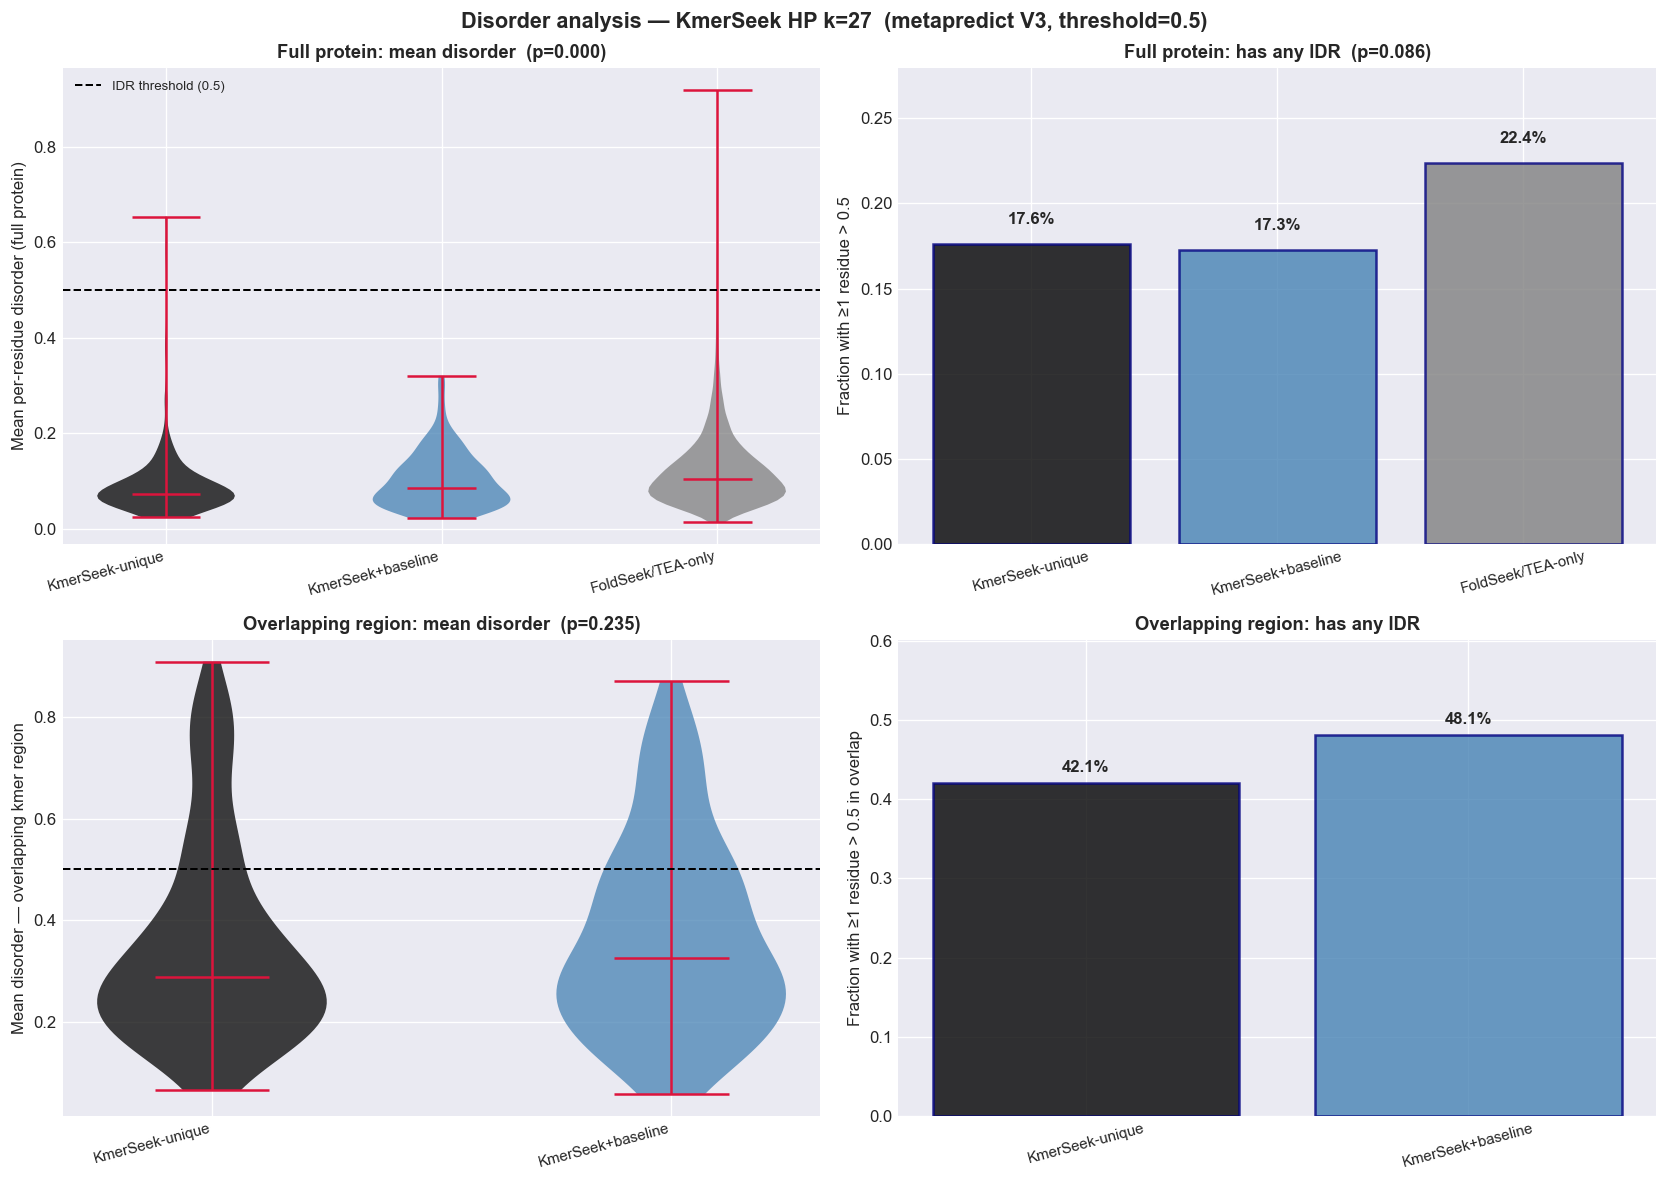

In [13]:
# ── Disorder enrichment: full protein + overlapping regions ───────────────────
# Two metrics per protein:
#   1. mean_disorder      — mean per-residue score across full sequence (how disordered overall)
#   2. has_any_IDR        — whether the full protein contains ≥1 IDR (any region > threshold)
# Plus, for each KmerSeek hit:
#   3. overlap_disorder   — mean disorder score of the overlapping kmer region specifically
import metapredict as meta
import numpy as np
from scipy.stats import mannwhitneyu

FASTA_PATH = '/Users/olga/data/scope/astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa'
IDR_THRESHOLD = 0.5   # metapredict default
_VALID = set('ACDEFGHIKLMNPQRSTVWY')

def clean(seq):
    return ''.join(aa for aa in seq.upper() if aa in _VALID)

# Parse FASTA
print(f'Parsing {FASTA_PATH} ...')
seqs = {}
domain_id = None; buf = []
with open(FASTA_PATH) as fh:
    for line in fh:
        line = line.strip()
        if line.startswith('>'):
            if domain_id: seqs[domain_id] = ''.join(buf)
            domain_id = line[1:].split()[0]; buf = []
        else:
            buf.append(line)
if domain_id: seqs[domain_id] = ''.join(buf)
print(f'  Parsed {len(seqs):,} sequences')

km_unique_ids = km_det_all - base_detected
km_shared_ids = km_det_all & base_detected
fs_only_ids   = base_detected - km_det_all
groups = {'KmerSeek-unique': km_unique_ids,
          'KmerSeek+baseline': km_shared_ids,
          'FoldSeek/TEA-only': fs_only_ids}

# ── 1 & 2: Full-protein disorder ──────────────────────────────────────────────
group_full = {}
for grp_name, ids in groups.items():
    seq_dict = {qid: clean(seqs[qid]) for qid in ids if qid in seqs and seqs[qid]}
    _cache_full = BENCH_DIR / f'disorder_full_{grp_name.replace("+","_").replace("-","_").replace("/","_")}_k{k_plot}.parquet'
    if _cache_full.exists():
        print(f'  Loading cached full-protein disorder — {grp_name}')
        preds = {row['domain']: [row['sequence'], np.array(row['scores'].split(','), dtype=float)]
                 for row in pl.read_parquet(_cache_full).iter_rows(named=True)}
    else:
        print(f'  metapredict (full protein) — {grp_name}: {len(seq_dict)} seqs...')
        preds = meta.predict_disorder(seq_dict, normalized=True,
                                      return_domains=False, show_progress_bar=False)
        pl.DataFrame([{'domain': qid, 'sequence': v[0],
                       'scores': ','.join(f'{x:.4f}' for x in v[1])}
                      for qid, v in preds.items()]).write_parquet(_cache_full)
        print(f'    Cached to {_cache_full.name}')
    rows = []
    for qid, v in preds.items():
        scores = np.array(v[1])
        rows.append({'domain': qid,
                     'mean_disorder': float(scores.mean()),
                     'has_any_IDR':   bool((scores > IDR_THRESHOLD).any()),
                     'frac_disordered': float((scores > IDR_THRESHOLD).mean())})
    group_full[grp_name] = rows
    print(f'    mean disorder = {np.mean([r["mean_disorder"] for r in rows]):.4f}  '
          f'  has_any_IDR = {np.mean([r["has_any_IDR"] for r in rows]):.1%}')

# ── 3: Overlapping-region disorder ────────────────────────────────────────────
results_path = BENCH_DIR / f'scope40.hp.k{k_plot}.results.csv.gz'
res = pl.read_csv(results_path).with_columns(
    pl.col('query_name').str.split(' ').list.get(0).alias('query_domain')
)
best_subseqs = (res
    .filter(pl.col('query_domain').is_in(km_unique_ids | km_shared_ids))
    .filter(pl.col('poisson_pvalue') < ALPHA)
    .filter(pl.col('query_subseq').is_not_null())
    .sort('poisson_pvalue')
    .group_by('query_domain')
    .agg(pl.first('query_subseq'))
)
subseq_map = dict(zip(best_subseqs['query_domain'].to_list(),
                      best_subseqs['query_subseq'].to_list()))

group_overlap = {}
for grp_name, ids in [('KmerSeek-unique', km_unique_ids),
                       ('KmerSeek+baseline', km_shared_ids)]:
    seq_dict = {qid: clean(subseq_map[qid])
                for qid in ids if qid in subseq_map and subseq_map[qid]}
    if not seq_dict:
        group_overlap[grp_name] = []
        continue
    _cache_ov = BENCH_DIR / f'disorder_overlap_{grp_name.replace("+","_").replace("-","_").replace("/","_")}_k{k_plot}.parquet'
    if _cache_ov.exists():
        print(f'  Loading cached overlap disorder — {grp_name}')
        preds = {row['domain']: [row['sequence'], np.array(row['scores'].split(','), dtype=float)]
                 for row in pl.read_parquet(_cache_ov).iter_rows(named=True)}
    else:
        print(f'  metapredict (overlap region) — {grp_name}: {len(seq_dict)} seqs...')
        preds = meta.predict_disorder(seq_dict, normalized=True,
                                      return_domains=False, show_progress_bar=False)
        pl.DataFrame([{'domain': qid, 'sequence': v[0],
                       'scores': ','.join(f'{x:.4f}' for x in v[1])}
                      for qid, v in preds.items()]).write_parquet(_cache_ov)
        print(f'    Cached to {_cache_ov.name}')
    rows = []
    for qid, v in preds.items():
        scores = np.array(v[1])
        rows.append({'domain': qid,
                     'overlap_mean_disorder': float(scores.mean()),
                     'overlap_has_IDR':       bool((scores > IDR_THRESHOLD).any())})
    group_overlap[grp_name] = rows
    print(f'    overlap mean disorder = {np.mean([r["overlap_mean_disorder"] for r in rows]):.4f}')

# ── Summary table ─────────────────────────────────────────────────────────────
print()
print(f'{"Group":<22} {"n":>5}  {"mean disorder":>14}  {"has ANY IDR":>12}  {"mean frac IDR":>14}')
print('-' * 74)
for grp in groups:
    rows = group_full[grp]
    if not rows: continue
    vals  = np.array([r['mean_disorder'] for r in rows])
    f_idr = np.mean([r['has_any_IDR'] for r in rows])
    f_frac = np.mean([r['frac_disordered'] for r in rows])
    print(f'{grp:<22} {len(rows):>5}  {vals.mean():>14.4f}  {f_idr:>12.1%}  {f_frac:>14.1%}')

print()
print(f'{"Group":<22} {"n":>5}  {"overlap mean":>13}  {"overlap has IDR":>16}')
print('-' * 62)
for grp in ['KmerSeek-unique', 'KmerSeek+baseline']:
    rows = group_overlap.get(grp, [])
    if not rows: continue
    vals  = np.array([r['overlap_mean_disorder'] for r in rows])
    f_idr = np.mean([r['overlap_has_IDR'] for r in rows])
    print(f'{grp:<22} {len(rows):>5}  {vals.mean():>13.4f}  {f_idr:>16.1%}')

# ── Stats ─────────────────────────────────────────────────────────────────────
u_rows = group_full['KmerSeek-unique']
b_rows = group_full['FoldSeek/TEA-only']
u_mean  = np.array([r['mean_disorder']    for r in u_rows])
b_mean  = np.array([r['mean_disorder']    for r in b_rows])
u_has   = np.array([r['has_any_IDR']      for r in u_rows], dtype=float)
b_has   = np.array([r['has_any_IDR']      for r in b_rows], dtype=float)
stat_m, p_mean = mannwhitneyu(u_mean, b_mean, alternative='two-sided')
stat_h, p_has  = mannwhitneyu(u_has,  b_has,  alternative='two-sided')
print(f'\nMann-Whitney (KmerSeek-unique vs FoldSeek/TEA-only):')
print(f'  mean disorder:   U={stat_m:.0f}  p={p_mean:.4f}')
print(f'  has_any_IDR:     U={stat_h:.0f}  p={p_has:.4f}')

ov_u = np.array([r['overlap_mean_disorder'] for r in group_overlap.get('KmerSeek-unique',[])])
ov_s = np.array([r['overlap_mean_disorder'] for r in group_overlap.get('KmerSeek+baseline',[])])
if len(ov_u) and len(ov_s):
    stat_o, p_ov = mannwhitneyu(ov_u, ov_s, alternative='two-sided')
    print(f'  overlap disorder (unique vs shared): U={stat_o:.0f}  p={p_ov:.4f}')

# ── Plots ─────────────────────────────────────────────────────────────────────
colors = ['black', 'steelblue', 'grey']
VIOLIN_LINE_COLOR = 'crimson'   # IQR / median lines inside violins
BAR_EDGE_COLOR    = 'navy'      # bar chart outlines

def _style_violin_lines(parts):
    """Color all inner violin lines (bars, whiskers, medians) crimson."""
    for key in ('cbars', 'cmedians', 'cmins', 'cmaxes'):
        if key in parts:
            parts[key].set_color(VIOLIN_LINE_COLOR)
            parts[key].set_linewidth(1.5)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (0,0) Mean full-protein disorder — violin
ax = axes[0,0]
data = [[r['mean_disorder'] for r in group_full[g]] for g in groups]
parts = ax.violinplot(data, positions=range(len(groups)), showmedians=True)
for pc, col in zip(parts['bodies'], colors): pc.set_facecolor(col); pc.set_alpha(0.75)
_style_violin_lines(parts)
ax.axhline(IDR_THRESHOLD, color='black', ls='--', lw=1.2, label=f'IDR threshold ({IDR_THRESHOLD})')
ax.set_xticks(range(len(groups))); ax.set_xticklabels(list(groups), fontsize=9, rotation=15, ha='right')
ax.set_ylabel('Mean per-residue disorder (full protein)', fontsize=10)
ax.set_title(f'Full protein: mean disorder  (p={p_mean:.3f})', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)

# (0,1) Fraction with ANY IDR — bar
ax = axes[0,1]
fracs = [np.mean([r['has_any_IDR'] for r in group_full[g]]) for g in groups]
bars = ax.bar(list(groups), fracs, color=colors, alpha=0.8, edgecolor=BAR_EDGE_COLOR, linewidth=1.5)
for bar, f in zip(bars, fracs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{f:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel(f'Fraction with ≥1 residue > {IDR_THRESHOLD}', fontsize=10)
ax.set_title(f'Full protein: has any IDR  (p={p_has:.3f})', fontsize=11, fontweight='bold')
ax.tick_params(axis='x', labelsize=9, rotation=15); ax.set_ylim(0, max(fracs)*1.25)

# (1,0) Overlapping region mean disorder — violin
ax = axes[1,0]
ov_groups = ['KmerSeek-unique', 'KmerSeek+baseline']
ov_data   = [[r['overlap_mean_disorder'] for r in group_overlap.get(g,[])] for g in ov_groups]
if any(ov_data):
    parts = ax.violinplot(ov_data, positions=range(len(ov_groups)), showmedians=True)
    for pc, col in zip(parts['bodies'], colors): pc.set_facecolor(col); pc.set_alpha(0.75)
    _style_violin_lines(parts)
ax.axhline(IDR_THRESHOLD, color='black', ls='--', lw=1.2)
ax.set_xticks(range(len(ov_groups))); ax.set_xticklabels(ov_groups, fontsize=9, rotation=15, ha='right')
ax.set_ylabel('Mean disorder — overlapping kmer region', fontsize=10)
ax.set_title(f'Overlapping region: mean disorder' + (f'  (p={p_ov:.3f})' if len(ov_u) and len(ov_s) else ''),
             fontsize=11, fontweight='bold')

# (1,1) Overlapping region has IDR — bar
ax = axes[1,1]
ov_fracs = [np.mean([r['overlap_has_IDR'] for r in group_overlap.get(g,[])]) for g in ov_groups]
bars = ax.bar(ov_groups, ov_fracs, color=colors[:2], alpha=0.8, edgecolor=BAR_EDGE_COLOR, linewidth=1.5)
for bar, f in zip(bars, ov_fracs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{f:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel(f'Fraction with ≥1 residue > {IDR_THRESHOLD} in overlap', fontsize=10)
ax.set_title('Overlapping region: has any IDR', fontsize=11, fontweight='bold')
ax.tick_params(axis='x', labelsize=9, rotation=15); ax.set_ylim(0, max(ov_fracs or [1])*1.25)

plt.suptitle(f'Disorder analysis — KmerSeek HP k={k_plot}  (metapredict V3, threshold={IDR_THRESHOLD})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/068_hp_unique_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Families Unique to KmerSeek (not in FoldSeek or TEA)

In [14]:
# Extract SCOP family labels for unique queries
def get_families(rocx_df: pl.DataFrame, query_set: set) -> list:
    """Get list of SCOP family labels (first 4 parts of SCOP lineage)."""
    subset = rocx_df.filter(pl.col('NAME').is_in(query_set))
    families = []
    for scop in subset['SCOP'].to_list():
        if not scop:
            continue
        parts = scop.split('.')
        if len(parts) >= 4:
            families.append('.'.join(parts[:4]))
        elif len(parts) == 3:
            families.append(scop)
    return families


km_unique_ids = km_det_all - base_detected
fams_unique   = get_families(km_rocx[k_plot], km_unique_ids)
fams_all_km   = get_families(km_rocx[k_plot], km_det_all)

unique_families = set(fams_unique)
print(f'Families in KmerSeek-unique detections: {len(unique_families)}')
print(f'Total KmerSeek families (detected):     {len(set(fams_all_km))}')
pct_unique_fam = 100 * len(unique_families) / len(set(fams_all_km)) if fams_all_km else 0
print(f'Fraction unique: {pct_unique_fam:.1f}%')
print()

# Top families by count
fam_counts = Counter(fams_unique)
print(f'Top 20 KmerSeek-unique families (by query count):')
for fam, cnt in fam_counts.most_common(20):
    cls = fam[0] if fam else '?'
    desc = SCOPE_CLASS_DESCRIPTIONS.get(cls, '?')
    print(f'  {fam:<15} n={cnt:>2}  class {cls} ({desc[:40]})')


Families in KmerSeek-unique detections: 76
Total KmerSeek families (detected):     130
Fraction unique: 58.5%

Top 20 KmerSeek-unique families (by query count):
  d.144.1.0       n=22  class d (Alpha and beta proteins (a+b) — segregat)
  c.2.1.0         n=20  class c (Alpha and beta proteins (a/b) — alternat)
  a.104.1.0       n=15  class a (All alpha proteins)
  c.37.1.0        n=10  class c (Alpha and beta proteins (a/b) — alternat)
  c.14.1.0        n= 7  class c (Alpha and beta proteins (a/b) — alternat)
  b.47.1.1        n= 5  class b (All beta proteins)
  c.95.1.0        n= 5  class c (Alpha and beta proteins (a/b) — alternat)
  c.93.1.0        n= 5  class c (Alpha and beta proteins (a/b) — alternat)
  a.128.1.0       n= 5  class a (All alpha proteins)
  c.94.1.0        n= 5  class c (Alpha and beta proteins (a/b) — alternat)
  c.2.1.2         n= 4  class c (Alpha and beta proteins (a/b) — alternat)
  b.36.1.0        n= 4  class b (All beta proteins)
  c.69.1.0        n= 4  class

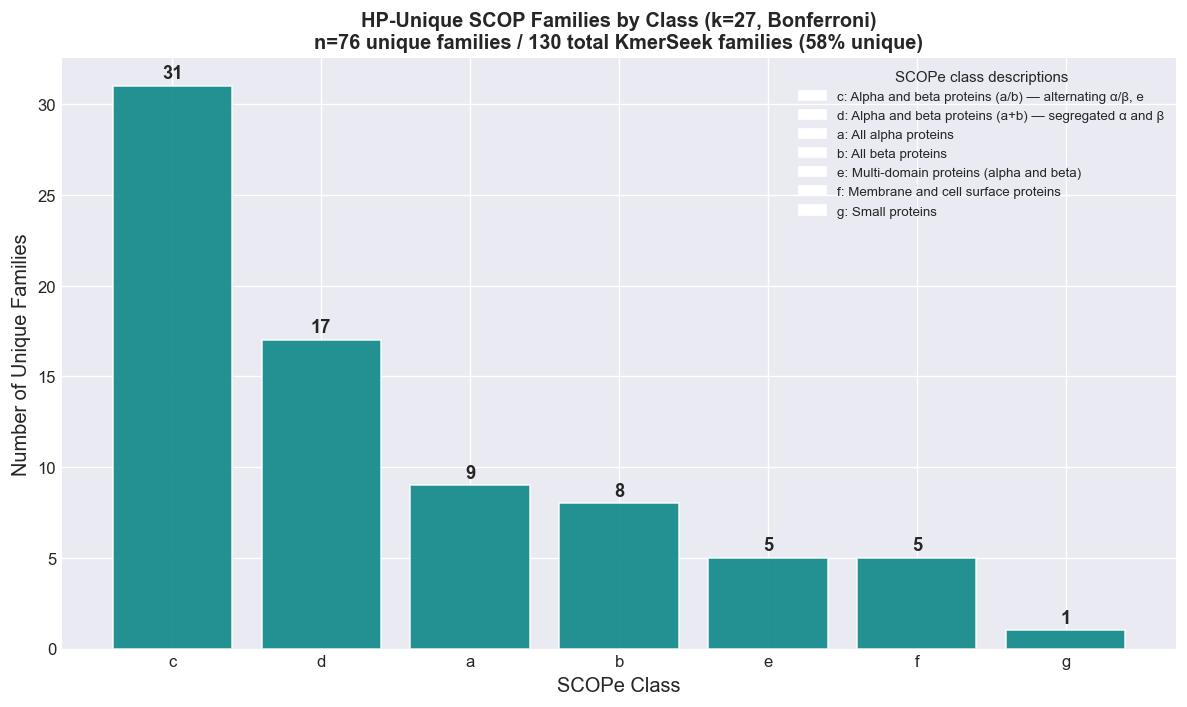

In [15]:
# Unique families by class
class_fam_counts = {}
for fam in unique_families:
    cls = fam[0] if fam else '?'
    class_fam_counts[cls] = class_fam_counts.get(cls, 0) + 1

classes_sorted = sorted(class_fam_counts, key=lambda c: -class_fam_counts[c])
counts_sorted  = [class_fam_counts[c] for c in classes_sorted]
labels_sorted  = [f'{c}: {SCOPE_CLASS_DESCRIPTIONS.get(c, c)[:30]}'
                  for c in classes_sorted]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(classes_sorted, counts_sorted, color='teal', alpha=0.85, edgecolor='white')
for bar, val in zip(bars, counts_sorted):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            str(val), ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_xlabel('SCOPe Class', fontsize=12)
ax.set_ylabel('Number of Unique Families', fontsize=12)
ax.set_title(
    f'HP-Unique SCOP Families by Class (k={k_plot}, Bonferroni)\n'
    f'n={len(unique_families)} unique families / {len(set(fams_all_km))} total KmerSeek families '
    f'({pct_unique_fam:.0f}% unique)',
    fontsize=12, fontweight='bold',
)
# Add description as legend
handles = [mpatches.Patch(color='white', label=f'{c}: {SCOPE_CLASS_DESCRIPTIONS.get(c, c)[:50]}')
           for c in classes_sorted]
ax.legend(handles=handles, fontsize=8, loc='upper right',
          title='SCOPe class descriptions', title_fontsize=9)

plt.tight_layout()
plt.savefig('../figures/068_unique_families_by_class.png', dpi=150, bbox_inches='tight')
plt.show()


In [16]:
from scipy.stats import mannwhitneyu
import numpy as np

print('=' * 90)
print(f'SUMMARY: KmerSeek HP k={k_plot} — Benchmark & Unique Hits Analysis')
print('=' * 90)

# ── 1. Sensitivity AUC ────────────────────────────────────────────────────────
print('\n### 1. Sensitivity AUC  (covered-query, pval<{ALPHA}, Jaccard)\n'.format(ALPHA=ALPHA))
print(f'  {"Method":<40} {"SFAM":>8} {"FAM":>8} {"FOLD":>8}  n_queries')
print(f'  {"-"*75}')
for name, df in [('FoldSeek', foldseek), ('TEA', tea_all)]:
    _, _, s  = sensitivity_stats(df, 'SFAM')
    _, _, fa = sensitivity_stats(df, 'FAM')
    _, _, fo = sensitivity_stats(df, 'FOLD')
    print(f'  {name:<40} {s:>8.4f} {fa:>8.4f} {fo:>8.4f}  {df["NAME"].n_unique():,}')
_, _, s  = sensitivity_stats(km_rocx_r[k_plot], 'SFAM')
_, _, fa = sensitivity_stats(km_rocx_r[k_plot], 'FAM')
_, _, fo = sensitivity_stats(km_rocx_r[k_plot], 'FOLD')
print(f'  {f"KmerSeek k={k_plot} pval<{ALPHA} Jaccard":<40} {s:>8.4f} {fa:>8.4f} {fo:>8.4f}  {km_rocx_r[k_plot]["NAME"].n_unique():,}')

# ── 2. Unique hits ────────────────────────────────────────────────────────────
print(f'\n### 2. Unique Hits  (SFAM sensitivity > 0, KmerSeek only)\n')
n_det  = len(km_det_all)
n_uniq = len(km_unique_ids)
n_shr  = len(km_shared_ids)
print(f'  KmerSeek detected:         {n_det:,}  queries')
print(f'  Unique to KmerSeek:        {n_uniq:,}  ({100*n_uniq/n_det:.1f}% of KmerSeek hits)')
print(f'  Shared with FoldSeek/TEA:  {n_shr:,}')

# ── 3. SCOPe class enrichment ─────────────────────────────────────────────────
# Test A: HP-unique vs FoldSeek (enrichment_pval from cell 7620a29f)
# Test B: HP-unique vs HP-shared (rows/fdr from Fisher test cell ee483ed2, BH-corrected)
print(f'\n### 3. SCOPe Class Enrichment  (one-sided Fisher exact)\n')
print(f'  Test A — HP-unique vs FoldSeek detected (is class over-represented in HP vs structure tools?)')
print(f'  Test B — HP-unique vs HP-shared (is class over-represented in unique vs shared KmerSeek hits?)\n')
print(f'  {"Cls":<4} {"Description":<32}  {"HP%":>6} {"FS%":>6}  {"OR-B":>6} {"p-A":>8}  {"p-B":>8} {"FDR-B":>8}')
print(f'  {"-"*90}')
for idx, (cls, n_u, n_s, OR_B, pval_B) in enumerate(fisher_rows):
    desc    = SCOPE_CLASS_DESCRIPTIONS.get(cls, '?')[:31]
    hp_pct  = pct_km_unique.get(cls, 0)
    fs_pct  = pct_fs.get(cls, 0)
    p_A     = enrichment_pval(cls)
    sig     = '***' if fisher_fdr[idx] < 0.001 else ('**' if fisher_fdr[idx] < 0.01 else ('*' if fisher_fdr[idx] < 0.05 else ''))
    or_str  = f'{OR_B:.2f}' if np.isfinite(OR_B) else 'inf'
    print(f'  {cls:<4} {desc:<32}  {hp_pct:>6.1f} {fs_pct:>6.1f}  {or_str:>6} {p_A:>8.4f}  {pval_B:>8.4f} {fisher_fdr[idx]:>8.4f}  {sig}')
print(f'  OR-B: odds ratio (HP-unique vs HP-shared, >1 = enriched in unique set)')
print(f'  FDR-B: Benjamini-Hochberg across classes')

# ── 4. Intrinsic Disorder ─────────────────────────────────────────────────────
print(f'\n### 4. Intrinsic Disorder  (metapredict V3, threshold={IDR_THRESHOLD})\n')
print(f'  {"Group":<24} {"n":>5}  {"mean disorder":>14}  {"has ANY IDR":>12}  {"frac IDR":>10}')
print(f'  {"-"*70}')
for grp in group_full:
    r = group_full[grp]
    if not r: continue
    vals  = np.array([x['mean_disorder'] for x in r])
    f_idr = np.mean([x['has_any_IDR']    for x in r])
    f_frc = np.mean([x['frac_disordered'] for x in r])
    print(f'  {grp:<24} {len(r):>5}  {vals.mean():>14.4f}  {f_idr:>12.1%}  {f_frc:>10.1%}')
print()
print(f'  Mann-Whitney (KmerSeek-unique vs FoldSeek/TEA-only):')
print(f'    mean disorder:   p = {p_mean:.4f}  {"*" if p_mean < 0.05 else "n.s."}')
print(f'    has any IDR:     p = {p_has:.4f}  {"*" if p_has  < 0.05 else "n.s."}')
_p_ov = p_ov if 'p_ov' in dir() else None
if _p_ov is not None:
    print(f'    overlap region:  p = {_p_ov:.4f}  {"*" if _p_ov < 0.05 else "n.s."}')

# ── 5. Sequence similarity in matched regions ─────────────────────────────────
print(f'\n### 5. Sequence Similarity in Matched kmer Regions  (Mann-Whitney: same SFAM vs diff SFAM)\n')
if 'pair_df' in dir() and len(pair_df) > 0:
    print(f'  {"Metric":<22}  {"mean":>8}  {"same-SFAM":>10}  {"diff-SFAM":>10}  {"p-value":>10}')
    print(f'  {"-"*68}')
    for col in ['%identity', '%similarity', 'HP jaccard', 'overlap disorder', 'log10(pvalue)']:
        if col not in pair_df.columns:
            continue
        vals = pair_df[col].dropna()
        same = pair_df.loc[pair_df['same SFAM'],  col].dropna()
        diff = pair_df.loc[~pair_df['same SFAM'], col].dropna()
        if len(same) > 1 and len(diff) > 1:
            _, p = mannwhitneyu(same, diff, alternative='two-sided')
            p_str = f'{p:.2e}' if p < 0.001 else f'{p:.3f}'
            sig   = ' *' if p < 0.05 else ''
        else:
            p_str, sig = 'n/a', ''
        print(f'  {col:<22}  {vals.mean():>8.2f}  {same.mean() if len(same) else float("nan"):>10.2f}  {diff.mean() if len(diff) else float("nan"):>10.2f}  {p_str:>10}{sig}')

# ── 6. SCOP coverage unique to KmerSeek ───────────────────────────────────────
print(f'\n### 6. SCOP Coverage Unique to KmerSeek  (k={k_plot}, queries with SFAM sens > 0)\n')

def _scop_ids_at_level(query_set, n_parts):
    ids = set()
    for scop in km_rocx[k_plot].filter(pl.col('NAME').is_in(query_set))['SCOP'].to_list():
        if scop:
            parts = scop.split('.')
            if len(parts) >= n_parts:
                ids.add('.'.join(parts[:n_parts]))
    return ids

print(f'  {"Level":<14} {"KmerSeek-unique":>16} {"KmerSeek-all":>14} {"% unique":>10}')
print(f'  {"-"*58}')
for level_name, n_parts in [('Class', 1), ('Fold', 2), ('Superfamily', 3), ('Family', 4)]:
    uniq_ids = _scop_ids_at_level(km_unique_ids, n_parts)
    all_ids  = _scop_ids_at_level(km_det_all,    n_parts)
    pct      = 100 * len(uniq_ids) / len(all_ids) if all_ids else 0
    print(f'  {level_name:<14} {len(uniq_ids):>16,} {len(all_ids):>14,} {pct:>9.1f}%')

print(f'\n  Top 10 unique families by n_queries:')
for fam, cnt in fam_counts.most_common(10):
    cls  = fam[0] if fam else '?'
    desc = SCOPE_CLASS_DESCRIPTIONS.get(cls, '?')[:35]
    print(f'    {fam:<15} n={cnt:>2}  class {cls}: {desc}')

print()
print('=' * 90)


SUMMARY: KmerSeek HP k=27 — Benchmark & Unique Hits Analysis

### 1. Sensitivity AUC  (covered-query, pval<0.001, Jaccard)

  Method                                       SFAM      FAM     FOLD  n_queries
  ---------------------------------------------------------------------------
  FoldSeek                                   0.5743   0.8169   0.1017  5,713
  TEA                                        0.5804   0.8020   0.0868  5,737
  KmerSeek k=27 pval<0.001 Jaccard           0.8643   0.8323   0.8739  156

### 2. Unique Hits  (SFAM sensitivity > 0, KmerSeek only)

  KmerSeek detected:         366  queries
  Unique to KmerSeek:        233  (63.7% of KmerSeek hits)
  Shared with FoldSeek/TEA:  133

### 3. SCOPe Class Enrichment  (one-sided Fisher exact)

  Test A — HP-unique vs FoldSeek detected (is class over-represented in HP vs structure tools?)
  Test B — HP-unique vs HP-shared (is class over-represented in unique vs shared KmerSeek hits?)

  Cls  Description                        

## 8. Plots: Sequence Similarity & SCOP Coverage

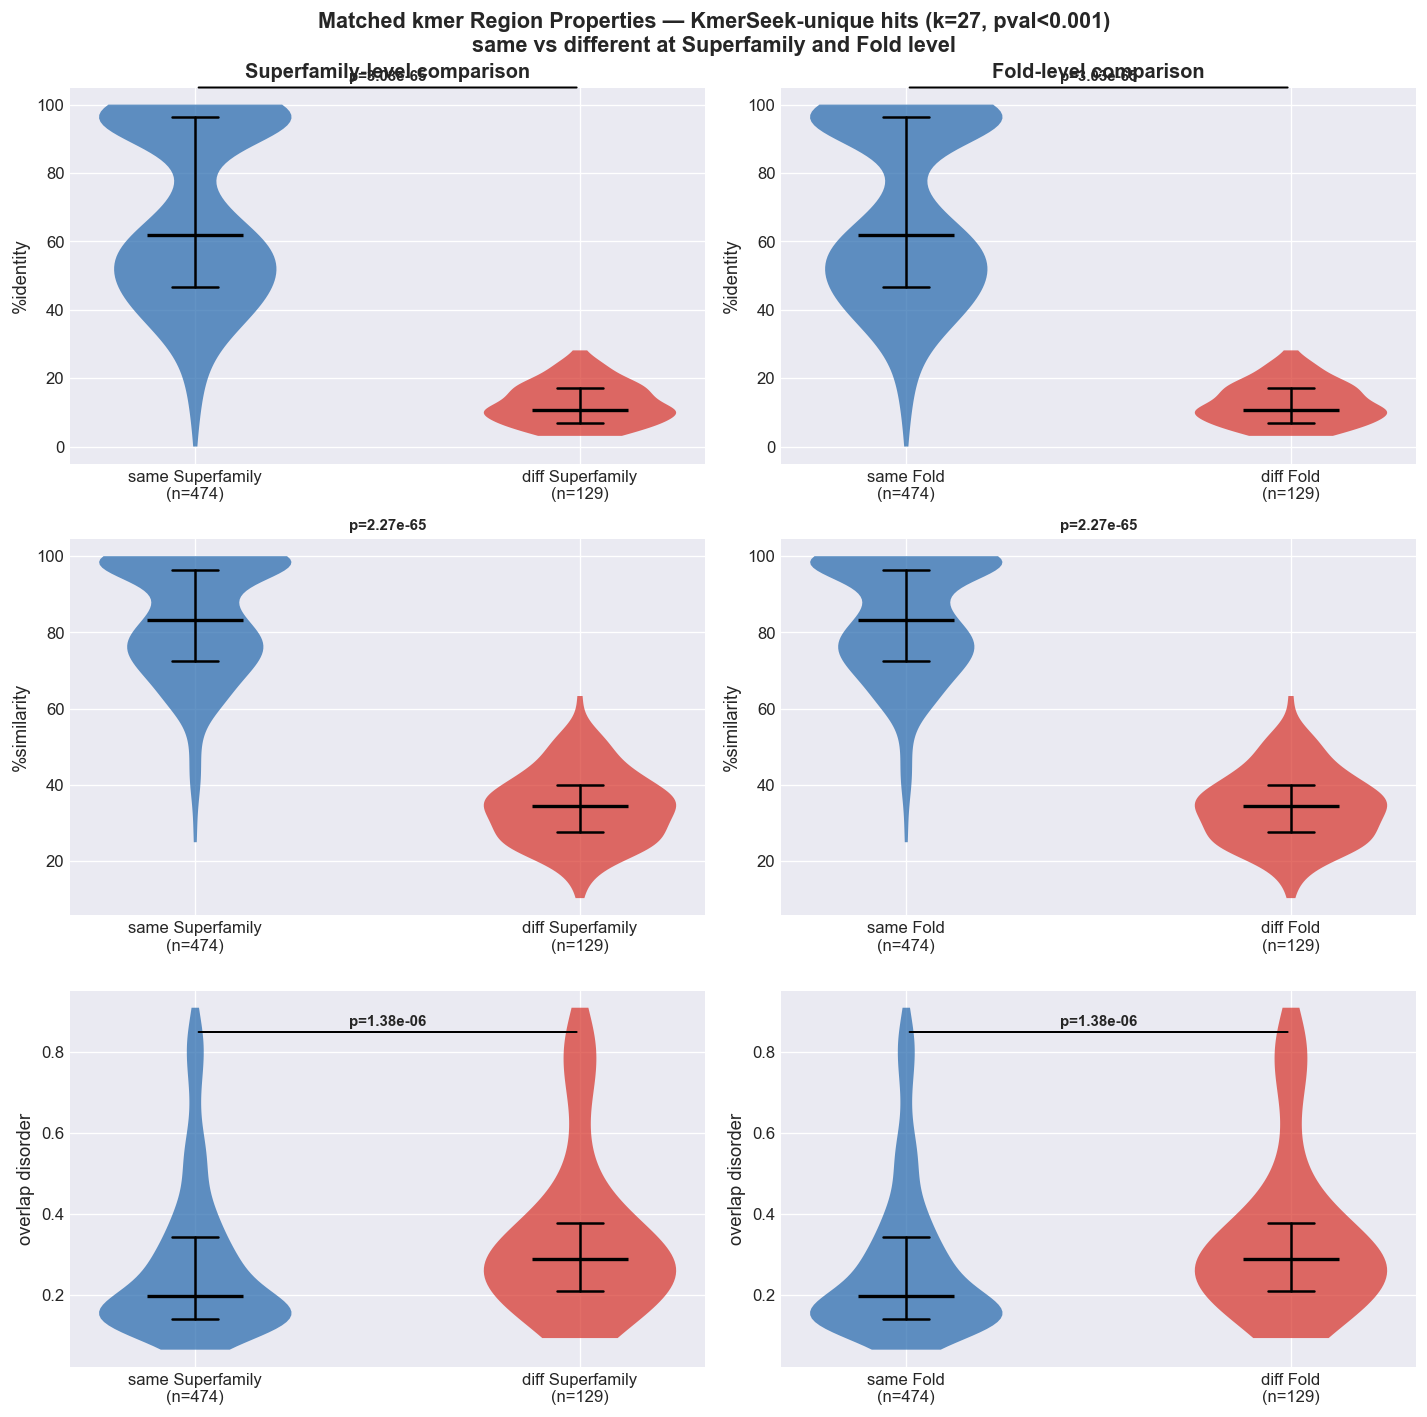

In [19]:
from scipy.stats import mannwhitneyu
import matplotlib.patches as mpatches

METRICS  = ['%identity', '%similarity', 'overlap disorder']
LEVELS   = [('SFAM', 'same SFAM', 'Superfamily'), ('FOLD', 'same FOLD', 'Fold')]
COLORS   = {'same': '#2166ac', 'diff': '#d73027'}

fig, axes = plt.subplots(len(METRICS), len(LEVELS), figsize=(12, 4 * len(METRICS)))
fig.suptitle(
    f'Matched kmer Region Properties — KmerSeek-unique hits (k={k_plot}, pval<{ALPHA})\n'
    f'same vs different at Superfamily and Fold level',
    fontsize=13, fontweight='bold')

for row, metric in enumerate(METRICS):
    if metric not in pair_df.columns:
        continue
    for col, (level_col, same_col, level_name) in enumerate(LEVELS):
        ax = axes[row, col]

        same_vals = pair_df.loc[ pair_df[same_col], metric].dropna().values
        diff_vals = pair_df.loc[~pair_df[same_col], metric].dropna().values

        # Violin plot
        parts = ax.violinplot([same_vals, diff_vals], positions=[0, 1],
                              showmedians=True, showextrema=False)
        for pc, color in zip(parts['bodies'], [COLORS['same'], COLORS['diff']]):
            pc.set_facecolor(color); pc.set_alpha(0.7)
        parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2)

        # Overlay box (IQR)
        for pos, vals, color in [(0, same_vals, COLORS['same']),
                                  (1, diff_vals, COLORS['diff'])]:
            q1, q3 = np.percentile(vals, [25, 75])
            ax.plot([pos - 0.06, pos + 0.06], [q1, q1], color='black', lw=1.5)
            ax.plot([pos - 0.06, pos + 0.06], [q3, q3], color='black', lw=1.5)
            ax.plot([pos, pos], [q1, q3], color='black', lw=1.5)

        # Mann-Whitney p-value annotation
        _, p = mannwhitneyu(same_vals, diff_vals, alternative='two-sided')
        p_str = f'p={p:.2e}' if p < 0.001 else f'p={p:.3f}'
        y_top = max(np.percentile(same_vals, 95), np.percentile(diff_vals, 95))
        y_ann = y_top * 1.05 if y_top > 0 else y_top + 5
        ax.annotate('', xy=(1, y_ann), xytext=(0, y_ann),
                    arrowprops=dict(arrowstyle='-', color='black', lw=1.2))
        ax.text(0.5, y_ann * 1.01 if y_ann > 0 else y_ann + 1,
                p_str, ha='center', va='bottom', fontsize=9, fontweight='bold')

        ax.set_xticks([0, 1])
        ax.set_xticklabels(
            [f'same {level_name}\n(n={len(same_vals):,})',
             f'diff {level_name}\n(n={len(diff_vals):,})'],
            fontsize=10)
        ax.set_ylabel(metric, fontsize=11)
        if row == 0:
            ax.set_title(f'{level_name}-level comparison', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/068_similarity_by_scop_level.png', dpi=150, bbox_inches='tight')
plt.show()

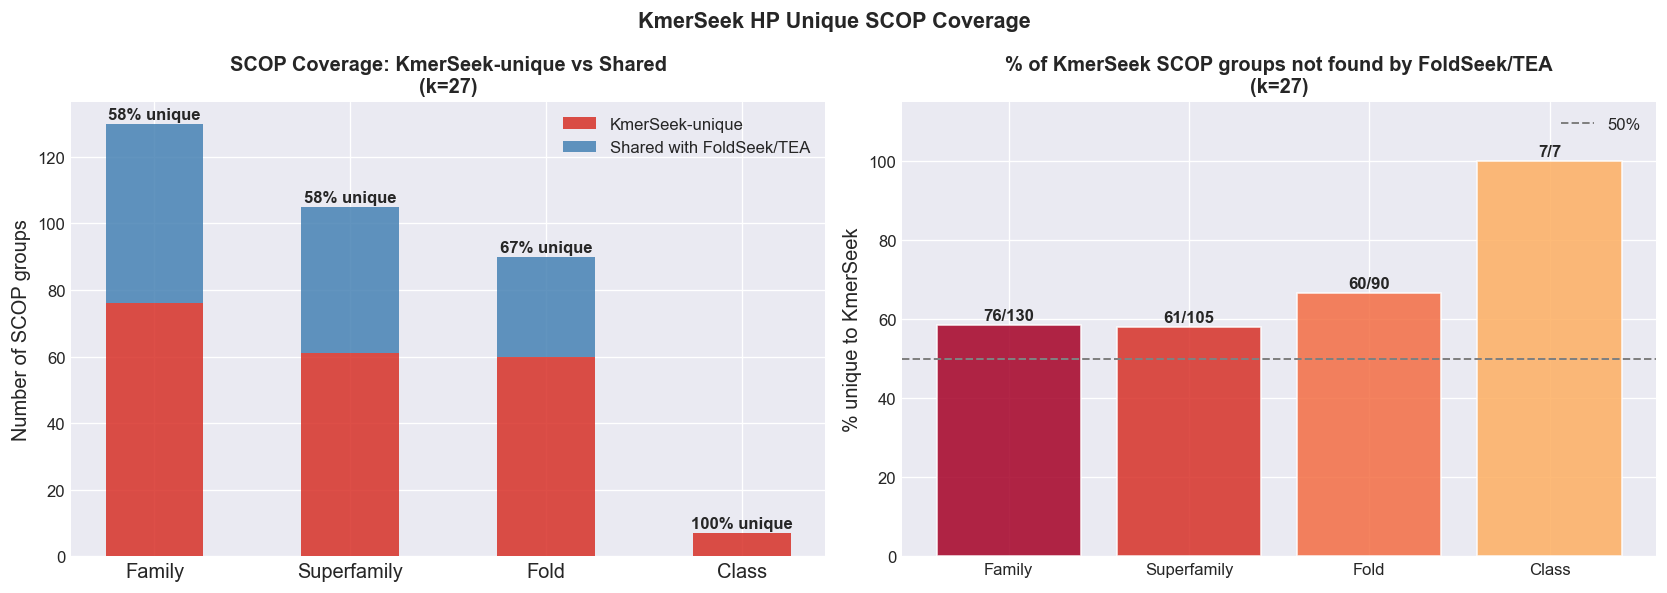

In [20]:
# ── SCOP coverage: unique vs all at each level ───────────────────────────────
def _scop_ids_at_level(query_set, n_parts):
    ids = set()
    for scop in km_rocx[k_plot].filter(pl.col('NAME').is_in(query_set))['SCOP'].to_list():
        if scop:
            parts = scop.split('.')
            if len(parts) >= n_parts:
                ids.add('.'.join(parts[:n_parts]))
    return ids

levels_def = list(reversed([('Class', 1), ('Fold', 2), ('Superfamily', 3), ('Family', 4)]))
level_names = [l for l, _ in levels_def]
n_unique_ids = [len(_scop_ids_at_level(km_unique_ids, n)) for _, n in levels_def]
n_all_ids    = [len(_scop_ids_at_level(km_det_all,    n)) for _, n in levels_def]
n_shared_ids = [a - u for a, u in zip(n_all_ids, n_unique_ids)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: stacked bar — unique vs shared
ax = axes[0]
x = np.arange(len(level_names))
w = 0.5
bars_u = ax.bar(x, n_unique_ids, width=w, label='KmerSeek-unique', color='#d73027', alpha=0.85)
bars_s = ax.bar(x, n_shared_ids, width=w, bottom=n_unique_ids, label='Shared with FoldSeek/TEA',
                color='steelblue', alpha=0.85)
for xi, (nu, na) in enumerate(zip(n_unique_ids, n_all_ids)):
    pct = 100 * nu / na if na else 0
    ax.text(xi, na + 0.5, f'{pct:.0f}% unique', ha='center', va='bottom',
            fontsize=10, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(level_names, fontsize=12)
ax.set_ylabel('Number of SCOP groups', fontsize=12)
ax.set_title(f'SCOP Coverage: KmerSeek-unique vs Shared\n(k={k_plot})',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)

# Right: % unique per level
ax = axes[1]
pct_unique = [100 * nu / na for nu, na in zip(n_unique_ids, n_all_ids)]
bars = ax.bar(level_names, pct_unique, color=['#a50026','#d73027','#f46d43','#fdae61'],
              alpha=0.85, edgecolor='white')
for bar, val, nu, na in zip(bars, pct_unique, n_unique_ids, n_all_ids):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{nu}/{na}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('% unique to KmerSeek', fontsize=12)
ax.set_ylim(0, 115)
ax.axhline(50, color='grey', ls='--', lw=1.2, label='50%')
ax.set_title(f'% of KmerSeek SCOP groups not found by FoldSeek/TEA\n(k={k_plot})',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)

plt.suptitle('KmerSeek HP Unique SCOP Coverage', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/068_scop_coverage_unique.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Top unique families barplot + unique vs shared hit properties ─────────────
import pandas as pd
from scipy.stats import mannwhitneyu
import matplotlib.patches as mpatches

TOP_N = 20
top_fams = fam_counts.most_common(TOP_N)

CLASS_COLORS = {
    'a': '#e41a1c', 'b': '#377eb8', 'c': '#4daf4a',
    'd': '#984ea3', 'e': '#ff7f00', 'f': '#a65628', 'g': '#f781bf',
}

# ── 1. Top unique families barplot ────────────────────────────────────────────
fig_fam, ax_fam = plt.subplots(figsize=(8, 7))
fam_labels  = [fam for fam, _ in top_fams]
fam_vals    = [n   for _,   n in top_fams]
bar_colors  = [CLASS_COLORS.get(fam[0], 'grey') for fam in fam_labels]

bars = ax_fam.barh(fam_labels[::-1], fam_vals[::-1], color=bar_colors[::-1], alpha=0.85)
for bar, val in zip(bars, fam_vals[::-1]):
    ax_fam.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2,
                f'n={val}', va='center', fontsize=9, fontweight='bold')

handles = [mpatches.Patch(color=v, label=f'Class {k}: {SCOPE_CLASS_DESCRIPTIONS.get(k,"")[:25]}')
           for k, v in CLASS_COLORS.items()
           if any(fam[0] == k for fam, _ in top_fams)]
ax_fam.legend(handles=handles, fontsize=8, loc='lower right')
ax_fam.set_xlabel('Number of KmerSeek-unique queries', fontsize=11)
ax_fam.set_title(f'Top {TOP_N} KmerSeek-unique SCOP families  (k={k_plot})',
                 fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/068_top_unique_families.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 2. Build hit-level dataframe for shared queries ───────────────────────────
print('Loading results for shared queries...')
_res = pl.read_csv(BENCH_DIR / f'scope40.hp.k{k_plot}.results.csv.gz').with_columns([
    pl.col('query_name').str.split(' ').list.get(0).alias('query_domain'),
    pl.col('target_name').str.split(' ').list.get(0).alias('target_domain'),
])

_BLOSUM62_POS = {
    frozenset(p) for p in [
        ('A','S'),('A','T'),('A','G'),('D','E'),('D','N'),('E','Q'),('E','K'),
        ('N','S'),('N','T'),('Q','K'),('R','K'),('I','L'),('I','V'),('I','M'),
        ('L','V'),('L','M'),('F','Y'),('F','W'),('Y','W'),('H','N'),('H','Q'),
        ('S','T'),('V','M'),
    ]
} | {frozenset((aa, aa)) for aa in 'ACDEFGHIKLMNPQRSTVWY'}

def _pct_id_sim(q_seq, t_seq):
    n = min(len(q_seq), len(t_seq))
    if n == 0:
        return np.nan, np.nan
    n_id  = sum(q == t for q, t in zip(q_seq, t_seq))
    n_sim = sum(frozenset((q.upper(), t.upper())) in _BLOSUM62_POS
                for q, t in zip(q_seq, t_seq))
    return 100 * n_id / n, 100 * n_sim / n

# Load overlap disorder for shared queries (cached in cell 19)
_shared_disorder = {}
_cache_shared = BENCH_DIR / f'disorder_overlap_KmerSeek_baseline_k{k_plot}.parquet'
if _cache_shared.exists():
    for _row in pl.read_parquet(_cache_shared).iter_rows(named=True):
        _shared_disorder[_row['domain']] = np.array(_row['scores'].split(','), dtype=float)
    print(f'  Loaded {len(_shared_disorder):,} shared overlap disorder scores')
else:
    print(f'  WARNING: shared disorder cache not found at {_cache_shared}')

def _build_hit_df(query_set, overlap_disorder_cache):
    rows = []
    for row in (_res
                .filter(pl.col('query_domain').is_in(query_set))
                .filter(pl.col('poisson_pvalue') < ALPHA)
                .filter(pl.col('query_subseq').is_not_null())
                .sort('poisson_pvalue')
                .iter_rows(named=True)):
        q_seq = row['query_subseq'] or ''
        t_seq = row['target_subseq'] or ''
        if not q_seq or not t_seq:
            continue
        pid, psim = _pct_id_sim(q_seq, t_seq)
        ov = overlap_disorder_cache.get(row['query_domain'])
        rows.append({
            '%identity':        pid,
            '%similarity':      psim,
            'overlap disorder':  float(np.mean(ov)) if ov is not None else np.nan,
        })
    return pd.DataFrame(rows)

print('Building shared hit dataframe...')
shared_pair_df = _build_hit_df(km_shared_ids, _shared_disorder)
print(f'  KmerSeek-unique hits: {len(pair_df):,}  |  KmerSeek-shared hits: {len(shared_pair_df):,}')
del _res

# ── 3. Violin plots: unique vs shared ─────────────────────────────────────────
METRICS = ['%identity', '%similarity', 'overlap disorder']
fig, axes = plt.subplots(1, len(METRICS), figsize=(13, 5))

for ax, metric in zip(axes, METRICS):
    u_vals = pair_df[metric].dropna().values        if metric in pair_df.columns        else np.array([])
    s_vals = shared_pair_df[metric].dropna().values if metric in shared_pair_df.columns else np.array([])
    if len(u_vals) < 2 or len(s_vals) < 2:
        ax.set_title(f'{metric}\n(insufficient data)', fontsize=11)
        continue

    parts = ax.violinplot([u_vals, s_vals], positions=[0, 1],
                          showmedians=True, showextrema=False)
    for pc, col in zip(parts['bodies'], ['#d73027', 'steelblue']):
        pc.set_facecolor(col); pc.set_alpha(0.75)
    parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2)

    for pos, vals in [(0, u_vals), (1, s_vals)]:
        q1, q3 = np.percentile(vals, [25, 75])
        ax.plot([pos - 0.05, pos + 0.05], [q1, q1], 'k-', lw=1.5)
        ax.plot([pos - 0.05, pos + 0.05], [q3, q3], 'k-', lw=1.5)
        ax.plot([pos, pos], [q1, q3], 'k-', lw=1.5)

    _, p = mannwhitneyu(u_vals, s_vals, alternative='two-sided')
    p_str = f'p={p:.2e}' if p < 0.001 else f'p={p:.3f}'
    y_top = max(np.percentile(u_vals, 98), np.percentile(s_vals, 98))
    y_br  = y_top * 1.05 if y_top > 0 else y_top + 3
    ax.plot([0, 0, 1, 1], [y_br, y_br * 1.02, y_br * 1.02, y_br], 'k-', lw=1.2)
    ax.text(0.5, y_br * 1.03, p_str, ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(
        [f'KM-unique\n(n={len(u_vals):,})', f'KM-shared\n(n={len(s_vals):,})'],
        fontsize=10)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(
        f'{metric}\n'
        f'unique med={np.median(u_vals):.1f}  shared med={np.median(s_vals):.1f}',
        fontsize=11, fontweight='bold')

plt.suptitle(
    f'Hit Properties: KmerSeek-unique vs KmerSeek-shared with FoldSeek  (k={k_plot})',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/068_unique_vs_shared_hit_properties.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Verdict

**The unique-hit claim holds, on 233 queries.** At k=27 with p<0.001, kmerseek detects 366 queries
at superfamily level, of which 233 (63.7%) are detected by neither FoldSeek nor TEA. Against
FoldSeek's 5,421 and TEA's 5,214 detected queries this is a small addition, not a replacement, and
the AUC line has to be quoted with its n attached: SFAM 0.8643 / FAM 0.8323 / FOLD 0.8739 on
**156 queries**, against FoldSeek's 0.5743 / 0.8169 / 0.1017 on 5,713. The comparison is
coverage-limited by construction.

**Class c, e and f enrichment is statistically solid; the explanation for it is not tested here.**
Against FoldSeek's detected set (Test A), class c is over-represented at 47.2% vs 29.7%
(p<0.0001), class e at 3.4% vs 0.0% (p<0.0001), class f at 3.9% vs 1.1% (p=0.0023), and class b is
strongly under-represented at 9.0% vs 30.1%. Test B, which asks whether these classes are
over-represented in kmerseek's *unique* hits relative to its *shared* hits, survives nothing after
FDR correction (best are class d at 0.0861 and class e at 0.0903). So the enrichment is a property
of what kmerseek detects at all, not specifically of what it detects uniquely.

**Section 6's mechanism table and the sphingolipid pathway section are hypotheses written by hand,
not results from this notebook.** No computation here tests whether TIM-barrel HP alternation,
transmembrane H-runs, or the ceramide pathway enzymes explain the class-c/e/f enrichment. They are
plausible and they are the obvious next experiment; they should not be cited as findings of this
analysis.

**Roughly a quarter of the unique hits are not same-family.** Of 603 hits from the 233 unique
queries, 442 are same family, 474 same superfamily, 474 same fold, 521 same class. The alignment
dump makes the failure mode concrete: d1sj8a2 (Talin 1, a.216.1.1) hits d1f0xa2 (D-lactate
dehydrogenase, d.145.1.1) at 6.9% identity over a 29-residue region with disorder 0.91. Unique hits
are a mix of real remote homology and low-complexity or disordered-region artifacts, and this
notebook does not separate them. Notebook [086](./086_lowcomplexity_fraction_threshold.ipynb) is the
filter that addresses this.

**The disorder result is the opposite of the artifact story, at the whole-protein level.**
kmerseek-unique queries are *less* disordered than FoldSeek/TEA-only queries (mean 0.0912 vs 0.1265,
Mann-Whitney p<0.0001), and no more likely to carry any IDR (17.6% vs 22.4%, p=0.0864). But the
matched regions themselves average 0.3515 disorder, indistinguishable from the shared hits' 0.3700
(p=0.2355). Whole-protein disorder is not what drives kmerseek-unique detection; matched-region
disorder is high in both unique and shared hits, so it does not discriminate either.

**Family-level novelty is the strongest framing for a paper.** 76 of the 130 families kmerseek
detects (58.5%) appear only in its unique hits, concentrated in d.144.1.0 (n=22), c.2.1.0 (Rossmann,
n=20), a.104.1.0 (n=15) and c.37.1.0 (P-loop, n=10). Those are large, well-studied folds, so the
claim is about remote members of known families rather than about new families.